<h1 style="margin-bottom:4px;">1. Arquitetura e Observabilidade de Agentes</h1>

https://smith.langchain.com/
<p style="font-size:18px;margin-top:0;"><strong>Observabilidade inteligente para fluxos automatizados com LangSmith.</strong></p>

<div class="cf-bloco cf-conceito" style="background:#eaf1fd;color:#11223d;border-left:6px solid #2a5db0;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;font-size:15px;letter-spacing:0.3px;color:#11223d;">CASE CONDUTOR — COPAFIGURINHAS</p>
<p><strong>CopaFigurinhas — Observando a Qualidade de um Agente de Trocas.</strong></p>
<p>Um agente recebe pedidos de troca de figurinhas de um álbum fictício e precisa responder se a troca é justa.
Um pedido típico chega assim:</p>
<blockquote style="margin:10px 0;padding:10px 14px;border-left:4px solid #2a5db0;background:rgba(42,93,176,0.10);">
&ldquo;Tenho duas figurinhas 112 e uma 208 repetidas. Quero trocar pela figurinha 417. Essa troca é justa?&rdquo;
</blockquote>
<p>Antes de recomendar ou bloquear, o agente consulta o álbum do usuário, o catálogo, a raridade,
o valor relativo e as políticas de troca. Cada uma dessas etapas vira um sinal observável.</p>
<p>O problema desta aula não é fazer o agente responder. É descobrir se a resposta dele
<strong>merece confiança</strong> — e provar isso com evidências.</p>
</div>

<div class="cf-bloco cf-reflexao" style="background:#fff4e0;color:#3a2c05;border-left:6px solid #c98a00;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;font-size:15px;letter-spacing:0.3px;color:#3a2c05;">PERGUNTA OPERACIONAL DA AULA</p>
<p>Um agente terminou a execução sem erro. Isso é suficiente para liberar a recomendação dele para usuários reais?</p>
</div>

## 2. Agenda

| Bloco | Assunto | O que você produz |
|---|---|---|
| 1 | Case e arquitetura | O agente CopaFigurinhas rodando de ponta a ponta |
| 2 | Tracing | Traces nomeados, com tags e metadados |
| 3 | Investigação | Diagnóstico de um trace anômalo |
| 4 | Dashboards | Comparação entre duas versões do agente |
| 5 | Feedback | Sinais de qualidade pesquisáveis |
| 6 | Avaliações | Avaliadores determinísticos, LLM-as-a-Judge e experimentos |
| 7 | Alertas | Especificações acionáveis de alerta |

A lógica de trabalho é sempre a mesma:

`executar → observar → avaliar → comparar → detectar → decidir`

## 3. Objetivo

Ao final desta aula você será capaz de:

1. **Instrumentar** um fluxo LangGraph de forma que cada nó, ferramenta e chamada de modelo apareça nomeado no LangSmith.
2. **Separar** saúde técnica (status, latência, tokens, erros) de qualidade semântica (correção, fundamentação, conformidade).
3. **Correlacionar** execuções por tags, metadados e identificadores estáveis, e explicar por que campos de alta cardinalidade não servem como dimensão agregada.
4. **Investigar** uma execução anômala e apontar, com evidência, qual etapa causou a degradação.
5. **Transformar** uma interpretação em sinal: registrar feedback com chaves consistentes e agregá-las em dashboard.
6. **Avaliar** o agente com avaliadores determinísticos e com um juiz LLM sob rubrica explícita, sabendo quando cada um se aplica.
7. **Comparar** duas versões do agente em um experimento offline e decidir se o custo adicional trouxe ganho real.
8. **Especificar** alertas acionáveis e produzir uma decisão operacional com severidade, responsável e ação recomendada.

<div class="cf-bloco cf-conceito" style="background:#eaf1fd;color:#11223d;border-left:6px solid #2a5db0;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0;"><strong>Critério de sucesso mensurável:</strong> ao final, você deve conseguir responder
&ldquo;esta recomendação pode ir para produção?&rdquo; citando pelo menos três evidências de origens diferentes
(trace, dashboard, feedback ou avaliação).</p>
</div>

---

## Preparação do laboratório

<div class="cf-bloco cf-conceito" style="background:#eaf1fd;color:#11223d;border-left:6px solid #2a5db0;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;">PERGUNTA OPERACIONAL</p>
<p style="margin:0;">O que precisa estar configurado antes de a primeira execução gerar qualquer sinal confiável?</p>
</div>

Esta parte monta o laboratório: dependências, variáveis de ambiente, controles de segurança,
catálogo, álbuns, ferramentas, política e grafo. Nada aqui envia dados para fora da sua máquina
até que você autorize explicitamente.

### Instalação (opcional)

Execute a célula abaixo **somente** se o ambiente ainda não tiver as bibliotecas.
Se você já usa um ambiente preparado para a aula, pule esta célula.

In [ ]:
# Célula opcional de instalação. Não é necessária se o ambiente já está preparado.
# %pip install -U langgraph langchain-openai langsmith python-dotenv pandas pydantic

### Variáveis de ambiente

Crie (ou edite) um arquivo `.env` **na mesma pasta deste notebook** com as chaves abaixo.
Este notebook nunca escreve nesse arquivo — apenas lê.

```dotenv
OPENAI_API_KEY=
OPENAI_MODEL_AGENT=
OPENAI_MODEL_JUDGE=
OPENAI_MAX_OUTPUT_TOKENS=1000

LANGSMITH_API_KEY=
LANGSMITH_TRACING=true
LANGSMITH_PROJECT=copafigurinhas-observabilidade-inteligente
LANGSMITH_WORKSPACE_ID=
```

Observações:

- `OPENAI_MODEL_AGENT` é o modelo que **executa** o agente; `OPENAI_MODEL_JUDGE` é o modelo que **avalia** a qualidade. Manter os dois separados permite trocar o avaliador sem mexer no agente.
- `OPENAI_MAX_OUTPUT_TOKENS` limita o tamanho da resposta e, portanto, o custo por execução.
- `LANGSMITH_TRACING=true` habilita o tracing automático de LangChain e LangGraph.
- `LANGSMITH_WORKSPACE_ID` é **opcional**: só é necessário quando a sua chave de API dá acesso a mais de um workspace e o serviço exige a seleção explícita. Se a chave já está vinculada a um único workspace, deixe em branco.

<div class="cf-bloco cf-seguranca" style="background:#fdeaea;color:#3d1414;border-left:6px solid #c0392b;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;">ATENÇÃO</p>
<p style="margin:0;">Tudo que é enviado ao tracing pode tornar-se pesquisável por usuários autorizados do workspace.
Use apenas os dados fictícios deste notebook.</p>
</div>

In [28]:
"""Importações e leitura da configuração. Nenhuma chamada externa acontece aqui."""

from __future__ import annotations

import os
import statistics
import time
import uuid
from typing import Any, Callable, Literal, TypedDict

import pandas as pd
from dotenv import load_dotenv
from IPython.display import HTML, display
from pydantic import BaseModel, Field

load_dotenv(override=True)

OPENAI_API_KEY: str | None = os.getenv("OPENAI_API_KEY")
MODELO_AGENTE: str = os.getenv("OPENAI_MODEL_AGENT", "gpt-5-nano")
MODELO_JUIZ: str = os.getenv("OPENAI_MODEL_JUDGE", "gpt-5-mini")
MAX_OUTPUT_TOKENS: int = int(os.getenv("OPENAI_MAX_OUTPUT_TOKENS", "1000"))

LANGSMITH_API_KEY: str | None = os.getenv("LANGSMITH_API_KEY")
LANGSMITH_PROJECT: str = os.getenv(
    "LANGSMITH_PROJECT", "copafigurinhas-observabilidade-inteligente"
)
LANGSMITH_WORKSPACE_ID: str | None = os.getenv("LANGSMITH_WORKSPACE_ID") or None

# Sessão desta execução do notebook: permite reencontrar no LangSmith tudo que
# foi gerado hoje, sem depender de horário.
SESSION_ID: str = f"aula-{uuid.uuid4().hex[:8]}"

print("Modelo do agente :", MODELO_AGENTE)
print("Modelo do juiz   :", MODELO_JUIZ)
print("Max output tokens:", MAX_OUTPUT_TOKENS)
print("Projeto LangSmith:", LANGSMITH_PROJECT)
print("Workspace ID     :", LANGSMITH_WORKSPACE_ID or "(não informado — opcional)")
print("SESSION_ID       :", SESSION_ID)
print()
print("OPENAI_API_KEY encontrada   :", bool(OPENAI_API_KEY))
print("LANGSMITH_API_KEY encontrada:", bool(LANGSMITH_API_KEY))

Modelo do agente : gpt-5-nano
Modelo do juiz   : gpt-5-mini
Max output tokens: 3000
Projeto LangSmith: copafigurinhas-observabilidade-inteligente
Workspace ID     : (não informado — opcional)
SESSION_ID       : aula-0eadb948

OPENAI_API_KEY encontrada   : True
LANGSMITH_API_KEY encontrada: True


### Controles de segurança

Este notebook faz chamadas pagas e envia dados para um serviço externo. Por isso, **nada acontece por padrão**.
Cada categoria de ação tem uma autorização própria, e o notebook interrompe com mensagem clara
quando a autorização está desligada — ele nunca substitui uma chamada real por resposta simulada.

In [3]:
"""Controles de segurança. Altere para True apenas o que você quer executar agora."""

AUTORIZAR_CHAMADAS_REAIS = True   # chamadas à OpenAI (agente)
AUTORIZAR_ENVIO_LANGSMITH = True  # envio de traces e feedback ao LangSmith
AUTORIZAR_CRIAR_DATASET = True    # criação/atualização do dataset offline
AUTORIZAR_AVALIACAO_LLM = True    # execução do juiz LLM

MAX_CASOS_DEMO = 6   # casos distintos por versão do agente
MAX_CASOS_JUDGE = 3  # casos avaliados pelo juiz LLM


class AutorizacaoNecessaria(RuntimeError):
    """Erro levantado quando uma ação exige autorização explícita."""


def exigir(condicao: bool, mensagem: str) -> None:
    """Interrompe a execução com mensagem acionável quando a condição falha."""
    if not condicao:
        raise AutorizacaoNecessaria(mensagem)


def exigir_chamadas_reais() -> None:
    exigir(
        AUTORIZAR_CHAMADAS_REAIS,
        "AUTORIZAR_CHAMADAS_REAIS está False. Nenhuma chamada à OpenAI será feita e "
        "nenhuma resposta será simulada. Defina AUTORIZAR_CHAMADAS_REAIS = True e "
        "execute novamente.",
    )
    exigir(
        bool(OPENAI_API_KEY),
        "OPENAI_API_KEY não encontrada. Preencha o arquivo .env antes de continuar.",
    )


def exigir_envio_langsmith() -> None:
    exigir(
        AUTORIZAR_ENVIO_LANGSMITH,
        "AUTORIZAR_ENVIO_LANGSMITH está False. Nenhum trace ou feedback será enviado. "
        "Defina AUTORIZAR_ENVIO_LANGSMITH = True para observar no LangSmith.",
    )
    exigir(
        bool(LANGSMITH_API_KEY),
        "LANGSMITH_API_KEY não encontrada. Preencha o arquivo .env antes de continuar.",
    )


def exigir_dataset() -> None:
    exigir(
        AUTORIZAR_CRIAR_DATASET,
        "AUTORIZAR_CRIAR_DATASET está False. Nenhum dataset será criado ou alterado.",
    )


def exigir_juiz() -> None:
    exigir(
        AUTORIZAR_AVALIACAO_LLM,
        "AUTORIZAR_AVALIACAO_LLM está False. O juiz LLM não será executado e nenhuma "
        "nota será inventada.",
    )


def prever_chamadas(quantidade_casos: int, versoes: list[str], etapa: str) -> None:
    """Mostra o custo previsto antes de qualquer execução em lote."""
    exigir(
        quantidade_casos <= MAX_CASOS_DEMO,
        f"{quantidade_casos} casos excedem MAX_CASOS_DEMO={MAX_CASOS_DEMO}.",
    )
    total = quantidade_casos * len(versoes)
    print(f"[{etapa}] previsão de execução")
    print(f"  casos                      : {quantidade_casos} (limite {MAX_CASOS_DEMO})")
    print(f"  versões                    : {', '.join(versoes)}")
    print(f"  chamadas à LLM do agente   : até {total} (1 por caso e versão)")
    print(f"  modelo do agente           : {MODELO_AGENTE}")
    print(f"  chamadas de juiz previstas : 0 nesta etapa (limite {MAX_CASOS_JUDGE})")
    print(f"  chamadas reais autorizadas : {AUTORIZAR_CHAMADAS_REAIS}")
    print(f"  envio ao LangSmith         : {AUTORIZAR_ENVIO_LANGSMITH}")


CONTADOR = {"llm_agente": 0, "llm_juiz": 0, "traces_enviados": 0}

print("Controles de segurança carregados. Todas as autorizações começam desligadas.")

Controles de segurança carregados. Todas as autorizações começam desligadas.


## ======== TESTE =============

In [4]:
import time
from langsmith import traceable


@traceable(
    name="langsmith.setup.check",
    run_type="chain",
    tags=["setup", "dia-3", "sem-llm"],
    metadata={
        "aula": "observabilidade-inteligente",
        "environment": "aula",
        "case": "teste-configuracao",
    },
)
def testar_langsmith(valor: int) -> dict:
    time.sleep(0.2)

    return {
        "entrada": valor,
        "resultado": valor * 2,
        "status": "configuracao_validada",
    }


resultado_teste = testar_langsmith(21)
resultado_teste

{'entrada': 21, 'resultado': 42, 'status': 'configuracao_validada'}

In [5]:
import os

from langchain_openai import ChatOpenAI
from langchain_core.tracers.langchain import wait_for_all_tracers


modelo = ChatOpenAI(
    model=os.environ["OPENAI_MODEL_AGENT"],
    temperature=0,
)


config_teste = {
    "run_name": "copafigurinhas.primeira_chamada",
    "tags": [
        "copafigurinhas",
        "dia-3",
        "primeiro-teste-llm",
    ],
    "metadata": {
        "case_id": "SETUP-001",
        "agent_version": "setup",
        "scenario_type": "conexao",
        "environment": "aula",
    },
}


try:
    resposta = modelo.invoke(
        "Responda apenas: LangSmith configurado.",
        config=config_teste,
    )

    print(resposta.content)
finally:
    wait_for_all_tracers()

LangSmith configurado.


In [6]:
import os
from langsmith import traceable
from langchain_openai import ChatOpenAI
from langchain_core.tracers.langchain import wait_for_all_tracers


modelo = ChatOpenAI(
    model=os.environ["OPENAI_MODEL_AGENT"],
    temperature=0,
)


CATALOGO_SETUP = {
    "112": {
        "raridade": "comum",
        "valor_relativo": 1,
    },
    "417": {
        "raridade": "rara",
        "valor_relativo": 4,
    },
}


@traceable(
    name="tool.consultar_catalogo",
    run_type="tool",
)
def consultar_catalogo_setup(codigos: list[str]) -> dict:
    return {
        codigo: CATALOGO_SETUP.get(codigo)
        for codigo in codigos
    }


@traceable(
    name="copafigurinhas.run",
    run_type="chain",
    tags=[
        "copafigurinhas",
        "dia-3",
        "primeiro-fluxo",
    ],
    metadata={
        "case_id": "SETUP-002",
        "agent_version": "setup",
        "scenario_type": "troca-simples",
        "environment": "aula",
    },
)
def analisar_troca_setup(pedido: str) -> dict:
    catalogo = consultar_catalogo_setup(["112", "417"])

    resposta = modelo.invoke(
        [
            {
                "role": "system",
                "content": (
                    "Analise brevemente uma troca de figurinhas usando "
                    "somente os dados fornecidos."
                ),
            },
            {
                "role": "user",
                "content": (
                    f"Pedido: {pedido}\n"
                    f"Catálogo: {catalogo}"
                ),
            },
        ]
    )

    return {
        "pedido": pedido,
        "catalogo": catalogo,
        "recomendacao": resposta.content,
    }


try:
    resultado = analisar_troca_setup(
        "Oferecer a figurinha 112 pela figurinha 417."
    )

    print(resultado["recomendacao"])
finally:
    wait_for_all_tracers()

Análise breve com base no catálogo fornecido:

- 112: valor_relativo 1 (raridade comum)
- 417: valor_relativo 4 (raridade rara)

Conclusão: a troca proposta (112 pela 417) é desbalanceada, pois 417 vale quatro vezes mais que 112. Para uma troca equilibrada, quem oferece deveria receber figurinhas com valor_relativo total igual a 4. Com apenas 112 (valor 1), faltam 3 unidades de valor.

Possíveis contrapropostas, usando apenas o que seria equivalente em valor:
- Oferecer 112 mais 3 figurinhas comuns adicionais (valor total 4) em troca da 417.
- Ou combinar 112 com outras figurinhas de valor_relativo somando 3 para igualar o valor de 417.

Observação: 417 é rara, o que explica o valor relativo mais alto em relação a 112.


## ================= FIM TESTE ===================

### Catálogo, álbuns e política

<div class="cf-bloco cf-conceito" style="background:#eaf1fd;color:#11223d;border-left:6px solid #2a5db0;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;">CONCEITO</p>
<p style="margin:0;">Um agente observável precisa de <strong>fontes de verdade separadas</strong>. O catálogo diz o que existe,
o álbum diz o que o usuário tem, e a política diz o que é permitido. Quando essas três fontes ficam misturadas
dentro do prompt, fica impossível saber se o erro foi de dado, de raciocínio ou de regra.</p>
</div>

Todos os nomes, seleções e identificadores abaixo são **fictícios**. Nenhum dado pessoal real é usado.

In [7]:
"""Catálogo fictício do álbum CopaFigurinhas: 20 figurinhas."""

Raridade = Literal["comum", "incomum", "rara", "lendária"]


class Figurinha(BaseModel):
    codigo: str
    jogador: str
    selecao: str
    raridade: Raridade
    valor_relativo: float = Field(gt=0)
    especial: bool = False
    disponivel_para_troca: bool = True


_CATALOGO_BRUTO: list[dict[str, Any]] = [
    {"codigo": "101", "jogador": "Tibério Ravel",  "selecao": "Aurora",         "raridade": "comum",    "valor_relativo": 1.0,  "especial": False, "disponivel_para_troca": True},
    {"codigo": "105", "jogador": "Nuno Estrela",   "selecao": "Aurora",         "raridade": "comum",    "valor_relativo": 1.2,  "especial": False, "disponivel_para_troca": True},
    {"codigo": "112", "jogador": "Kaito Serra",    "selecao": "Aurora",         "raridade": "incomum",  "valor_relativo": 2.5,  "especial": False, "disponivel_para_troca": True},
    {"codigo": "118", "jogador": "Elmo Vareda",    "selecao": "Aurora",         "raridade": "comum",    "valor_relativo": 1.1,  "especial": False, "disponivel_para_troca": True},
    {"codigo": "124", "jogador": "Íris Bandeira",  "selecao": "Aurora",         "raridade": "rara",     "valor_relativo": 6.0,  "especial": True,  "disponivel_para_troca": True},
    {"codigo": "201", "jogador": "Oriel Campo",    "selecao": "Montanha Azul",  "raridade": "comum",    "valor_relativo": 1.0,  "especial": False, "disponivel_para_troca": True},
    {"codigo": "208", "jogador": "Bruno Talhado",  "selecao": "Montanha Azul",  "raridade": "incomum",  "valor_relativo": 3.0,  "especial": False, "disponivel_para_troca": True},
    {"codigo": "215", "jogador": "Sara Montez",    "selecao": "Montanha Azul",  "raridade": "rara",     "valor_relativo": 7.5,  "especial": False, "disponivel_para_troca": True},
    {"codigo": "222", "jogador": "Lino Praça",     "selecao": "Montanha Azul",  "raridade": "comum",    "valor_relativo": 1.3,  "especial": False, "disponivel_para_troca": False},
    {"codigo": "301", "jogador": "Ada Corvina",    "selecao": "Ilhas Verdes",   "raridade": "comum",    "valor_relativo": 1.0,  "especial": False, "disponivel_para_troca": True},
    {"codigo": "309", "jogador": "Petra Onda",     "selecao": "Ilhas Verdes",   "raridade": "incomum",  "valor_relativo": 2.8,  "especial": False, "disponivel_para_troca": True},
    {"codigo": "316", "jogador": "Vito Farol",     "selecao": "Ilhas Verdes",   "raridade": "rara",     "valor_relativo": 6.8,  "especial": False, "disponivel_para_troca": True},
    {"codigo": "323", "jogador": "Wanda Coral",    "selecao": "Ilhas Verdes",   "raridade": "lendária", "valor_relativo": 18.0, "especial": True,  "disponivel_para_troca": True},
    {"codigo": "401", "jogador": "Otto Ribanceira","selecao": "Vale do Sol",    "raridade": "comum",    "valor_relativo": 1.1,  "especial": False, "disponivel_para_troca": True},
    {"codigo": "409", "jogador": "Mira Duna",      "selecao": "Vale do Sol",    "raridade": "incomum",  "valor_relativo": 2.6,  "especial": False, "disponivel_para_troca": True},
    {"codigo": "417", "jogador": "Caio Lumen",     "selecao": "Vale do Sol",    "raridade": "rara",     "valor_relativo": 7.0,  "especial": False, "disponivel_para_troca": True},
    {"codigo": "425", "jogador": "Zaida Pluma",    "selecao": "Vale do Sol",    "raridade": "lendária", "valor_relativo": 20.0, "especial": True,  "disponivel_para_troca": True},
    {"codigo": "501", "jogador": "Hugo Cavaleiro", "selecao": "Serra Norte",    "raridade": "comum",    "valor_relativo": 1.0,  "especial": False, "disponivel_para_troca": True},
    {"codigo": "510", "jogador": "Nila Bruma",     "selecao": "Serra Norte",    "raridade": "incomum",  "valor_relativo": 2.4,  "especial": False, "disponivel_para_troca": True},
    {"codigo": "518", "jogador": "Rui Alcatéia",   "selecao": "Serra Norte",    "raridade": "rara",     "valor_relativo": 6.4,  "especial": False, "disponivel_para_troca": True},
]

CATALOGO: dict[str, Figurinha] = {
    item["codigo"]: Figurinha(**item) for item in _CATALOGO_BRUTO
}

print(f"Figurinhas no catálogo: {len(CATALOGO)}")
display(
    pd.DataFrame([f.model_dump() for f in CATALOGO.values()]).set_index("codigo")
)

Figurinhas no catálogo: 20


,jogador,selecao,raridade,valor_relativo,especial,disponivel_para_troca
codigo,,,,,,
101,Tibério Ravel,Aurora,comum,1.0,False,True
105,Nuno Estrela,Aurora,comum,1.2,False,True
112,Kaito Serra,Aurora,incomum,2.5,False,True
118,Elmo Vareda,Aurora,comum,1.1,False,True
124,Íris Bandeira,Aurora,rara,6.0,True,True
201,Oriel Campo,Montanha Azul,comum,1.0,False,True
208,Bruno Talhado,Montanha Azul,incomum,3.0,False,True
215,Sara Montez,Montanha Azul,rara,7.5,False,True
222,Lino Praça,Montanha Azul,comum,1.3,False,False


In [8]:
"""Três álbuns fictícios, com duplicadas e faltantes."""


class Album(BaseModel):
    usuario_id: str
    apelido: str
    email_ficticio: str
    quantidades: dict[str, int]

    def quantidade(self, codigo: str) -> int:
        return self.quantidades.get(codigo, 0)

    @property
    def duplicadas(self) -> dict[str, int]:
        return {c: q for c, q in self.quantidades.items() if q > 1}

    @property
    def faltantes(self) -> list[str]:
        return sorted(c for c in CATALOGO if self.quantidade(c) == 0)


ALBUNS: dict[str, Album] = {
    "usr_aurora_01": Album(
        usuario_id="usr_aurora_01",
        apelido="colecionador-aurora",
        email_ficticio="colecionador.aurora@exemplo.invalido",
        quantidades={
            "101": 3, "105": 1, "112": 3, "118": 4, "124": 1,
            "201": 2, "208": 2, "301": 1, "401": 5, "501": 2,
        },
    ),
    "usr_montanha_02": Album(
        usuario_id="usr_montanha_02",
        apelido="trocador-montanha",
        email_ficticio="trocador.montanha@exemplo.invalido",
        quantidades={
            "112": 1, "201": 3, "208": 3, "215": 2, "222": 2,
            "309": 1, "323": 2, "401": 1, "409": 2, "510": 3,
        },
    ),
    "usr_serra_03": Album(
        usuario_id="usr_serra_03",
        apelido="arquivista-serra",
        email_ficticio="arquivista.serra@exemplo.invalido",
        quantidades={
            "101": 1, "118": 2, "301": 4, "316": 1, "409": 1,
            "417": 2, "425": 2, "501": 3, "510": 1, "518": 2,
        },
    ),
}

for album in ALBUNS.values():
    print(
        f"{album.usuario_id}: {len(album.quantidades)} códigos, "
        f"{len(album.duplicadas)} duplicadas, {len(album.faltantes)} faltantes"
    )

usr_aurora_01: 10 códigos, 7 duplicadas, 10 faltantes
usr_montanha_02: 10 códigos, 7 duplicadas, 10 faltantes
usr_serra_03: 10 códigos, 6 duplicadas, 10 faltantes


### Política de troca

<div class="cf-bloco cf-seguranca" style="background:#fdeaea;color:#3d1414;border-left:6px solid #c0392b;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;">PRINCÍPIO DA AULA</p>
<p style="margin:0;font-size:17px;"><strong>&ldquo;Modelos explicam e recomendam; políticas validam e autorizam.&rdquo;</strong></p>
<p style="margin:8px 0 0 0;">A política é código determinístico. Ela roda <em>depois</em> da LLM e pode derrubar
qualquer recomendação. A LLM não tem poder de ignorar uma violação determinística.</p>
</div>

Cada regra tem um código estável (`POL-00x`). Códigos estáveis são o que permite filtrar,
contar e alertar sobre violações no LangSmith — uma frase livre de justificativa não permite.

| Código | Regra |
|---|---|
| POL-001 | Figurinha inexistente no catálogo invalida a troca |
| POL-002 | Somente figurinhas duplicadas podem ser oferecidas |
| POL-003 | A quantidade disponível não pode ficar negativa |
| POL-004 | Diferença de valor acima de 20% torna a troca injusta |
| POL-005 | Figurinha lendária envolvida exige confirmação humana |
| POL-006 | Troca envolvendo duas lendárias exige aprovação humana |
| POL-007 | Figurinha marcada como indisponível não pode ser negociada |

In [9]:
"""Tools do agente: pequenas, determinísticas e rastreáveis."""

from langsmith import traceable

LIMITE_DIFERENCA_PERCENTUAL = 20.0
LATENCIA_CATALOGO_LENTO_S = 2.5  # atraso determinístico, usado apenas no cenário lento


class FigurinhaInexistenteError(ValueError):
    """Código solicitado não existe no catálogo."""


@traceable(run_type="tool", name="tool.consultar_album")
def consultar_album(usuario_id: str) -> dict[str, Any]:
    """Retorna o álbum do usuário: quantidades, duplicadas e faltantes."""
    album = ALBUNS.get(usuario_id)
    if album is None:
        raise KeyError(
            f"Álbum inexistente para usuario_id={usuario_id!r}. "
            f"Usuários disponíveis: {sorted(ALBUNS)}"
        )
    return {
        "usuario_id": album.usuario_id,
        "apelido": album.apelido,
        "quantidades": dict(album.quantidades),
        "duplicadas": album.duplicadas,
        "total_faltantes": len(album.faltantes),
    }


@traceable(run_type="tool", name="tool.consultar_catalogo")
def consultar_catalogo(codigos: list[str], *, modo_lento: bool = False) -> dict[str, Any]:
    """Consulta o catálogo. Em modo_lento aplica um atraso fixo e determinístico."""
    if modo_lento:
        time.sleep(LATENCIA_CATALOGO_LENTO_S)

    encontrados: dict[str, dict[str, Any]] = {}
    ausentes: list[str] = []
    for codigo in codigos:
        figurinha = CATALOGO.get(codigo)
        if figurinha is None:
            ausentes.append(codigo)
        else:
            encontrados[codigo] = figurinha.model_dump()
    return {
        "consultados": list(codigos),
        "encontrados": encontrados,
        "ausentes": ausentes,
        "modo_lento": modo_lento,
        "latencia_artificial_s": LATENCIA_CATALOGO_LENTO_S if modo_lento else 0.0,
    }


@traceable(run_type="tool", name="tool.validar_inventario")
def validar_posse_e_duplicidade(
    album: dict[str, Any], oferecidas: dict[str, int]
) -> dict[str, Any]:
    """Verifica posse, duplicidade e saldo remanescente das figurinhas oferecidas."""
    quantidades: dict[str, int] = album["quantidades"]
    violacoes: list[dict[str, Any]] = []
    detalhes: list[dict[str, Any]] = []

    for codigo, quantidade in oferecidas.items():
        possui = quantidades.get(codigo, 0)
        saldo = possui - quantidade
        detalhes.append(
            {
                "codigo": codigo,
                "possui": possui,
                "oferece": quantidade,
                "saldo_apos_troca": saldo,
                "duplicada": possui > 1,
            }
        )
        if possui == 0:
            violacoes.append(
                {"regra": "POL-002", "codigo": codigo,
                 "motivo": "usuário não possui a figurinha oferecida"}
            )
        elif possui <= 1:
            violacoes.append(
                {"regra": "POL-002", "codigo": codigo,
                 "motivo": "figurinha não é duplicada; só duplicadas podem ser oferecidas"}
            )
        if saldo < 1:
            violacoes.append(
                {"regra": "POL-003", "codigo": codigo,
                 "motivo": f"saldo ficaria {saldo}; a coleção não pode perder o último exemplar"}
            )

    return {"ok": not violacoes, "violacoes": violacoes, "detalhes": detalhes}


@traceable(run_type="tool", name="tool.calcular_valor_da_oferta")
def calcular_valor_da_oferta(
    itens: dict[str, int], catalogo_consultado: dict[str, Any]
) -> dict[str, Any]:
    """Soma o valor relativo de um conjunto de figurinhas."""
    encontrados = catalogo_consultado["encontrados"]
    composicao: list[dict[str, Any]] = []
    total = 0.0
    for codigo, quantidade in itens.items():
        ficha = encontrados.get(codigo)
        if ficha is None:
            raise FigurinhaInexistenteError(
                f"Código {codigo!r} não existe no catálogo consultado."
            )
        subtotal = ficha["valor_relativo"] * quantidade
        total += subtotal
        composicao.append(
            {
                "codigo": codigo,
                "quantidade": quantidade,
                "raridade": ficha["raridade"],
                "valor_unitario": ficha["valor_relativo"],
                "subtotal": round(subtotal, 2),
            }
        )
    return {"valor_total": round(total, 2), "composicao": composicao}


@traceable(run_type="tool", name="tool.calcular_equidade")
def avaliar_equidade_da_troca(
    oferecidas: dict[str, int],
    solicitadas: dict[str, int],
    catalogo_consultado: dict[str, Any],
) -> dict[str, Any]:
    """Compara o valor oferecido com o valor solicitado e classifica o risco."""
    oferta = calcular_valor_da_oferta(oferecidas, catalogo_consultado)
    solicitacao = calcular_valor_da_oferta(solicitadas, catalogo_consultado)

    valor_oferta = oferta["valor_total"]
    valor_solicitacao = solicitacao["valor_total"]
    diferenca = (valor_oferta - valor_solicitacao) / valor_solicitacao * 100.0
    diferenca = round(diferenca, 2)
    justa = abs(diferenca) <= LIMITE_DIFERENCA_PERCENTUAL

    raridades = {
        item["raridade"] for item in oferta["composicao"] + solicitacao["composicao"]
    }
    if "lendária" in raridades:
        risco = "alto"
    elif not justa:
        risco = "medio" if abs(diferenca) <= 45 else "alto"
    else:
        risco = "baixo"

    return {
        "valor_oferta": valor_oferta,
        "valor_solicitacao": valor_solicitacao,
        "diferenca_percentual": diferenca,
        "troca_justa": justa,
        "risco": risco,
        "limite_percentual": LIMITE_DIFERENCA_PERCENTUAL,
        "composicao_oferta": oferta["composicao"],
        "composicao_solicitacao": solicitacao["composicao"],
    }


print("Tools registradas: tool.consultar_album, tool.consultar_catalogo, "
      "tool.validar_inventario, tool.calcular_valor_da_oferta, tool.calcular_equidade")

Tools registradas: tool.consultar_album, tool.consultar_catalogo, tool.validar_inventario, tool.calcular_valor_da_oferta, tool.calcular_equidade


In [10]:
"""Política determinística. Roda depois da LLM e prevalece sobre a recomendação."""

REGRAS_POLITICA: dict[str, str] = {
    "POL-001": "Figurinha inexistente no catálogo invalida a troca",
    "POL-002": "Somente figurinhas duplicadas podem ser oferecidas",
    "POL-003": "A quantidade disponível não pode ficar negativa",
    "POL-004": "Diferença de valor acima de 20% torna a troca injusta",
    "POL-005": "Figurinha lendária envolvida exige confirmação humana",
    "POL-006": "Troca envolvendo duas lendárias exige aprovação humana",
    "POL-007": "Figurinha marcada como indisponível não pode ser negociada",
}


@traceable(run_type="chain", name="policy.validar_troca")
def aplicar_politica_de_troca(
    catalogo_consultado: dict[str, Any],
    validacao_inventario: dict[str, Any],
    equidade: dict[str, Any] | None,
    recomendacao_llm: str,
) -> dict[str, Any]:
    """Aplica as regras POL-001..POL-007 e decide o status final da troca."""
    violacoes: list[dict[str, Any]] = []
    aprovacao_necessaria = False

    for codigo in catalogo_consultado["ausentes"]:
        violacoes.append(
            {"regra": "POL-001", "codigo": codigo,
             "motivo": "figurinha não existe no catálogo"}
        )

    violacoes.extend(validacao_inventario["violacoes"])

    for codigo, ficha in catalogo_consultado["encontrados"].items():
        if not ficha["disponivel_para_troca"]:
            violacoes.append(
                {"regra": "POL-007", "codigo": codigo,
                 "motivo": "figurinha marcada como indisponível para troca"}
            )

    lendarias: list[str] = []
    if equidade is not None:
        if not equidade["troca_justa"]:
            violacoes.append(
                {
                    "regra": "POL-004",
                    "codigo": "-",
                    "motivo": (
                        f"diferença de {equidade['diferenca_percentual']}% excede o "
                        f"limite de {equidade['limite_percentual']}%"
                    ),
                }
            )
        lendarias = [
            item["codigo"]
            for item in equidade["composicao_oferta"] + equidade["composicao_solicitacao"]
            if item["raridade"] == "lendária"
        ]
        if lendarias:
            aprovacao_necessaria = True
            violacoes.append(
                {"regra": "POL-005", "codigo": ",".join(lendarias),
                 "motivo": "figurinha lendária exige confirmação humana"}
            )
        if len(lendarias) >= 2:
            violacoes.append(
                {"regra": "POL-006", "codigo": ",".join(lendarias),
                 "motivo": "troca entre duas lendárias exige aprovação humana"}
            )

    bloqueantes = [v for v in violacoes if v["regra"] not in {"POL-005", "POL-006"}]

    if bloqueantes:
        status_politica = "bloqueada"
        status_final = "bloqueada"
    elif aprovacao_necessaria:
        status_politica = "requer_aprovacao_humana"
        status_final = "pendente_aprovacao_humana"
    else:
        status_politica = "aprovada"
        status_final = (
            "recomendada" if recomendacao_llm == "recomendar" else "nao_recomendada"
        )

    return {
        "status_politica": status_politica,
        "status_final": status_final,
        "aprovacao_necessaria": aprovacao_necessaria,
        "regras_violadas": sorted({v["regra"] for v in violacoes}),
        "violacoes": violacoes,
        "recomendacao_llm": recomendacao_llm,
        "politica_prevaleceu": (
            recomendacao_llm == "recomendar" and status_final != "recomendada"
        ),
    }


print("Política carregada:", ", ".join(REGRAS_POLITICA))

Política carregada: POL-001, POL-002, POL-003, POL-004, POL-005, POL-006, POL-007


### Estado do grafo e contratos de saída

O estado carrega **três famílias de campos**: identificadores de correlação (`case_id`, `session_id`,
`run_id`, `thread_id`), fatos apurados pelas ferramentas (`catalogo_consultado`, `validacao_inventario`,
`diferenca_percentual`) e a produção da LLM (`recomendacao`, `justificativa`, `evidencias_utilizadas`).

Manter as três famílias separadas é o que permite, mais tarde, responder à pergunta central da aula:
o erro veio do dado, do modelo ou da regra?

In [11]:
"""Estado do LangGraph e esquemas de saída estruturada."""


class EstadoTroca(TypedDict, total=False):
    # correlação
    case_id: str
    session_id: str
    run_id: str
    thread_id: str
    # pedido
    usuario_id: str
    pedido_original: str
    oferecidas: dict[str, int]
    solicitadas: dict[str, int]
    # fatos apurados pelas ferramentas
    album: dict[str, Any]
    catalogo_consultado: dict[str, Any]
    validacao_inventario: dict[str, Any]
    valor_oferta: float
    valor_solicitacao: float
    diferenca_percentual: float
    troca_justa: bool
    risco: str
    # decisão
    aprovacao_necessaria: bool
    status_politica: str
    recomendacao: str
    justificativa: str
    evidencias_utilizadas: list[str]
    incerteza: str
    # identidade da execução
    agent_version: str
    scenario_type: str
    status_final: str
    # telemetria local
    metricas: dict[str, Any]
    resposta: dict[str, Any]


RecomendacaoPossivel = Literal["recomendar", "nao_recomendar", "revisar"]


class RecomendacaoBasica(BaseModel):
    """Saída da versão v1_basica: recomendação e justificativa livre."""

    recomendacao: RecomendacaoPossivel
    justificativa: str = Field(min_length=1)


class RecomendacaoComEvidencias(BaseModel):
    """Saída da versão v2_evidencias: exige evidências e declaração de incerteza."""

    recomendacao: RecomendacaoPossivel
    justificativa: str = Field(min_length=1)
    evidencias_utilizadas: list[str] = Field(
        min_length=1,
        description="Fatos citados literalmente a partir dos dados fornecidos.",
    )
    incerteza: str = Field(
        min_length=1,
        description="O que não foi possível confirmar com os dados fornecidos.",
    )


VERSOES_AGENTE: list[str] = ["v1_basica", "v2_evidencias"]

print("Estado e contratos definidos. Versões do agente:", VERSOES_AGENTE)

Estado e contratos definidos. Versões do agente: ['v1_basica', 'v2_evidencias']


In [12]:
"""Construção do modelo e do nó que chama a LLM."""

from langchain_openai import ChatOpenAI

PROMPT_V1 = (
    "Você é um assistente de trocas de figurinhas do álbum CopaFigurinhas.\n"
    "Responda se a troca pedida é justa e recomende uma ação."
)

PROMPT_V2 = (
    "Você é o analista de trocas do álbum CopaFigurinhas.\n"
    "Use APENAS os dados estruturados fornecidos. Nunca invente figurinhas, códigos, "
    "raridades ou valores que não estejam nos dados.\n"
    "Regras de resposta:\n"
    "1. Explique por que a troca é justa ou injusta citando valores e percentuais dos dados.\n"
    "2. Liste em evidencias_utilizadas os fatos concretos que sustentam sua conclusão.\n"
    "3. Declare em incerteza o que os dados não permitem afirmar.\n"
    "4. Você RECOMENDA; você não AUTORIZA. A autorização final é da política determinística. "
    "Se houver figurinha lendária ou violação de regra, use 'revisar' ou 'nao_recomendar'."
)


def construir_llm(modelo: str, *, max_tokens: int) -> ChatOpenAI:
    """Cria o cliente do modelo com parâmetros compatíveis com a família escolhida."""
    parametros: dict[str, Any] = {"model": modelo, "max_tokens": max_tokens}
    if modelo.startswith("gpt-5") or modelo.startswith("o"):
        # Modelos de raciocínio: sem 'temperature' e com esforço mínimo,
        # caso contrário o orçamento de tokens é consumido antes da resposta.
        parametros["reasoning_effort"] = "minimal"
    else:
        parametros["temperature"] = 0
    return ChatOpenAI(**parametros)


def _contexto_v1(estado: EstadoTroca) -> str:
    return (
        f"Pedido do usuário: {estado['pedido_original']}\n"
        f"Figurinhas oferecidas (código: quantidade): {estado['oferecidas']}\n"
        f"Figurinhas solicitadas (código: quantidade): {estado['solicitadas']}"
    )


def _contexto_v2(estado: EstadoTroca) -> str:
    catalogo = estado["catalogo_consultado"]
    equidade = {
        "valor_oferta": estado.get("valor_oferta"),
        "valor_solicitacao": estado.get("valor_solicitacao"),
        "diferenca_percentual": estado.get("diferenca_percentual"),
        "troca_justa": estado.get("troca_justa"),
        "limite_percentual": LIMITE_DIFERENCA_PERCENTUAL,
        "risco": estado.get("risco"),
    }
    return (
        f"Pedido do usuário: {estado['pedido_original']}\n\n"
        f"OFERECIDAS: {estado['oferecidas']}\n"
        f"SOLICITADAS: {estado['solicitadas']}\n\n"
        f"CATÁLOGO CONSULTADO (encontrados): {catalogo['encontrados']}\n"
        f"CATÁLOGO CONSULTADO (ausentes): {catalogo['ausentes']}\n\n"
        f"ÁLBUM DO USUÁRIO (quantidades): {estado['album']['quantidades']}\n"
        f"DUPLICADAS: {estado['album']['duplicadas']}\n\n"
        f"VALIDAÇÃO DE INVENTÁRIO: {estado['validacao_inventario']}\n\n"
        f"CÁLCULO DE EQUIDADE: {equidade}\n\n"
        f"REGRAS DA POLÍTICA: {REGRAS_POLITICA}"
    )


def chamar_modelo(estado: EstadoTroca) -> dict[str, Any]:
    """Executa a única chamada à LLM do fluxo, nomeada como model.gerar_recomendacao."""
    exigir_chamadas_reais()

    versao = estado["agent_version"]
    if versao == "v1_basica":
        prompt, esquema, contexto = PROMPT_V1, RecomendacaoBasica, _contexto_v1(estado)
    elif versao == "v2_evidencias":
        prompt, esquema, contexto = (
            PROMPT_V2,
            RecomendacaoComEvidencias,
            _contexto_v2(estado),
        )
    else:
        raise ValueError(f"agent_version desconhecida: {versao!r}")

    llm = construir_llm(MODELO_AGENTE, max_tokens=MAX_OUTPUT_TOKENS)
    cadeia = llm.with_structured_output(esquema, method="json_schema", include_raw=True)

    # Metadados não são presumidos como herdados: são reassociados à chamada do modelo
    # para que as métricas de LLM possam ser agrupadas por versão e cenário.
    configuracao = {
        "run_name": "model.gerar_recomendacao",
        "tags": ["copafigurinhas", "modelo", estado["agent_version"]],
        "metadata": {
            "case_id": estado["case_id"],
            "session_id": estado["session_id"],
            "agent_version": estado["agent_version"],
            "scenario_type": estado["scenario_type"],
            "environment": "aula",
            "modelo": MODELO_AGENTE,
        },
    }

    bruto = cadeia.invoke(
        [("system", prompt), ("human", contexto)], config=configuracao
    )
    CONTADOR["llm_agente"] += 1

    analisado = bruto["parsed"]
    if analisado is None:
        erro = bruto.get("parsing_error")
        raise ValueError(
            "A LLM não retornou uma saída estruturada válida. Nenhuma resposta será "
            f"simulada. Erro de parsing: {erro!r}. Verifique OPENAI_MAX_OUTPUT_TOKENS "
            f"(atual: {MAX_OUTPUT_TOKENS}) e o modelo {MODELO_AGENTE}."
        )

    uso = getattr(bruto["raw"], "usage_metadata", None) or {}
    tokens = {
        "input_tokens": uso.get("input_tokens"),
        "output_tokens": uso.get("output_tokens"),
        "total_tokens": uso.get("total_tokens"),
    }

    return {
        "recomendacao": analisado.recomendacao,
        "justificativa": analisado.justificativa,
        "evidencias_utilizadas": getattr(analisado, "evidencias_utilizadas", []),
        "incerteza": getattr(analisado, "incerteza", ""),
        "tokens": tokens,
    }


print("Nó de modelo pronto. Uma única chamada de LLM por execução do grafo.")

Nó de modelo pronto. Uma única chamada de LLM por execução do grafo.


### O grafo

```
START → node.interpretar_pedido → node.consultar_dados → node.validar_inventario
      → node.calcular_equidade → node.gerar_recomendacao → node.aplicar_politica
      → node.responder → END
```

Os nomes dos nós usam prefixos (`node.`, `tool.`, `model.`, `policy.`) porque é assim que eles
aparecerão na árvore do trace no LangSmith. Um nome como `chamar_llm_2` obriga quem investiga
a abrir o run para descobrir o que ele faz; `model.gerar_recomendacao` já responde.

In [13]:
"""Nós do grafo. Cada nó registra sua própria duração no estado."""

from langgraph.graph import END, START, StateGraph


def _registrar_tempo(estado: EstadoTroca, nome: str, inicio: float) -> dict[str, Any]:
    metricas = dict(estado.get("metricas") or {})
    tempos = dict(metricas.get("tempos_ms") or {})
    tempos[nome] = round((time.perf_counter() - inicio) * 1000, 1)
    metricas["tempos_ms"] = tempos
    return metricas


def no_interpretar_pedido(estado: EstadoTroca) -> dict[str, Any]:
    inicio = time.perf_counter()
    oferecidas = {str(c): int(q) for c, q in estado["oferecidas"].items()}
    solicitadas = {str(c): int(q) for c, q in estado["solicitadas"].items()}
    for mapa, rotulo in ((oferecidas, "oferecidas"), (solicitadas, "solicitadas")):
        if not mapa:
            raise ValueError(f"O pedido não contém figurinhas {rotulo}.")
        if any(q <= 0 for q in mapa.values()):
            raise ValueError(f"Quantidades inválidas em {rotulo}: {mapa}")
    return {
        "oferecidas": oferecidas,
        "solicitadas": solicitadas,
        "metricas": _registrar_tempo(estado, "node.interpretar_pedido", inicio),
    }


def no_consultar_dados(estado: EstadoTroca) -> dict[str, Any]:
    inicio = time.perf_counter()
    album = consultar_album(estado["usuario_id"])
    codigos = list(estado["oferecidas"]) + list(estado["solicitadas"])
    modo_lento = bool((estado.get("metricas") or {}).get("catalogo_lento"))
    catalogo = consultar_catalogo(codigos, modo_lento=modo_lento)
    return {
        "album": album,
        "catalogo_consultado": catalogo,
        "metricas": _registrar_tempo(estado, "node.consultar_dados", inicio),
    }


def no_validar_inventario(estado: EstadoTroca) -> dict[str, Any]:
    inicio = time.perf_counter()
    validacao = validar_posse_e_duplicidade(estado["album"], estado["oferecidas"])
    return {
        "validacao_inventario": validacao,
        "metricas": _registrar_tempo(estado, "node.validar_inventario", inicio),
    }


def no_calcular_equidade(estado: EstadoTroca) -> dict[str, Any]:
    inicio = time.perf_counter()
    catalogo = estado["catalogo_consultado"]

    if catalogo["ausentes"]:
        # Sem catálogo completo não existe cálculo de equidade confiável.
        # O fato é registrado no estado em vez de ser preenchido com um valor inventado.
        atualizacao: dict[str, Any] = {
            "valor_oferta": 0.0,
            "valor_solicitacao": 0.0,
            "diferenca_percentual": 0.0,
            "troca_justa": False,
            "risco": "alto",
            "metricas": {
                **_registrar_tempo(estado, "node.calcular_equidade", inicio),
                "equidade_calculada": False,
            },
        }
        return atualizacao

    equidade = avaliar_equidade_da_troca(
        estado["oferecidas"], estado["solicitadas"], catalogo
    )
    metricas = _registrar_tempo(estado, "node.calcular_equidade", inicio)
    metricas["equidade_calculada"] = True
    metricas["equidade"] = equidade
    return {
        "valor_oferta": equidade["valor_oferta"],
        "valor_solicitacao": equidade["valor_solicitacao"],
        "diferenca_percentual": equidade["diferenca_percentual"],
        "troca_justa": equidade["troca_justa"],
        "risco": equidade["risco"],
        "metricas": metricas,
    }


def no_gerar_recomendacao(estado: EstadoTroca) -> dict[str, Any]:
    inicio = time.perf_counter()
    saida = chamar_modelo(estado)
    metricas = _registrar_tempo(estado, "node.gerar_recomendacao", inicio)
    metricas["tokens"] = saida["tokens"]
    metricas["chamadas_llm"] = int(metricas.get("chamadas_llm", 0)) + 1
    return {
        "recomendacao": saida["recomendacao"],
        "justificativa": saida["justificativa"],
        "evidencias_utilizadas": saida["evidencias_utilizadas"],
        "incerteza": saida["incerteza"],
        "metricas": metricas,
    }


def no_aplicar_politica(estado: EstadoTroca) -> dict[str, Any]:
    inicio = time.perf_counter()
    metricas_atuais = estado.get("metricas") or {}
    equidade = metricas_atuais.get("equidade") if metricas_atuais.get(
        "equidade_calculada"
    ) else None

    decisao = aplicar_politica_de_troca(
        catalogo_consultado=estado["catalogo_consultado"],
        validacao_inventario=estado["validacao_inventario"],
        equidade=equidade,
        recomendacao_llm=estado["recomendacao"],
    )
    metricas = _registrar_tempo(estado, "node.aplicar_politica", inicio)
    metricas["decisao_politica"] = decisao
    return {
        "status_politica": decisao["status_politica"],
        "status_final": decisao["status_final"],
        "aprovacao_necessaria": decisao["aprovacao_necessaria"],
        "metricas": metricas,
    }


def no_responder(estado: EstadoTroca) -> dict[str, Any]:
    inicio = time.perf_counter()
    decisao = (estado.get("metricas") or {}).get("decisao_politica", {})
    resposta = {
        "case_id": estado["case_id"],
        "usuario_id": estado["usuario_id"],
        "agent_version": estado["agent_version"],
        "scenario_type": estado["scenario_type"],
        "recomendacao": estado["recomendacao"],
        "justificativa": estado["justificativa"],
        "evidencias_utilizadas": estado.get("evidencias_utilizadas", []),
        "incerteza": estado.get("incerteza", ""),
        "valor_oferta": estado.get("valor_oferta"),
        "valor_solicitacao": estado.get("valor_solicitacao"),
        "diferenca_percentual": estado.get("diferenca_percentual"),
        "troca_justa": estado.get("troca_justa"),
        "risco": estado.get("risco"),
        "status_politica": estado["status_politica"],
        "aprovacao_necessaria": estado["aprovacao_necessaria"],
        "regras_violadas": decisao.get("regras_violadas", []),
        "violacoes": decisao.get("violacoes", []),
        "politica_prevaleceu": decisao.get("politica_prevaleceu", False),
        "status_final": estado["status_final"],
    }
    return {
        "resposta": resposta,
        "metricas": _registrar_tempo(estado, "node.responder", inicio),
    }


def construir_grafo():
    """Monta e compila o grafo do agente CopaFigurinhas."""
    grafo = StateGraph(EstadoTroca)
    grafo.add_node("node.interpretar_pedido", no_interpretar_pedido)
    grafo.add_node("node.consultar_dados", no_consultar_dados)
    grafo.add_node("node.validar_inventario", no_validar_inventario)
    grafo.add_node("node.calcular_equidade", no_calcular_equidade)
    grafo.add_node("node.gerar_recomendacao", no_gerar_recomendacao)
    grafo.add_node("node.aplicar_politica", no_aplicar_politica)
    grafo.add_node("node.responder", no_responder)

    grafo.add_edge(START, "node.interpretar_pedido")
    grafo.add_edge("node.interpretar_pedido", "node.consultar_dados")
    grafo.add_edge("node.consultar_dados", "node.validar_inventario")
    grafo.add_edge("node.validar_inventario", "node.calcular_equidade")
    grafo.add_edge("node.calcular_equidade", "node.gerar_recomendacao")
    grafo.add_edge("node.gerar_recomendacao", "node.aplicar_politica")
    grafo.add_edge("node.aplicar_politica", "node.responder")
    grafo.add_edge("node.responder", END)
    return grafo.compile()


AGENTE = construir_grafo()
print("Grafo compilado com os nós:")
for nome in AGENTE.get_graph().nodes:
    print("  -", nome)

Grafo compilado com os nós:
  - __start__
  - node.interpretar_pedido
  - node.consultar_dados
  - node.validar_inventario
  - node.calcular_equidade
  - node.gerar_recomendacao
  - node.aplicar_politica
  - node.responder
  - __end__


### Cenários

Seis cenários cobrem os comportamentos que interessa observar: o caminho feliz, duas formas de
recusa por regra, uma falha de dado, uma degradação técnica e um caso que exige intervenção humana.

Cada cenário declara o **comportamento esperado**. Esse campo vai para os metadados do trace e é o que
permite, depois, perguntar ao dashboard: *o agente fez o que deveria neste tipo de situação?*

In [14]:
"""Os seis cenários da aula."""


class Cenario(BaseModel):
    case_id: str
    scenario_type: str
    usuario_id: str
    pedido: str
    oferecidas: dict[str, int]
    solicitadas: dict[str, int]
    risk_level: Literal["baixo", "medio", "alto"]
    approval_required: bool
    expected_behavior: str
    dataset_split: str
    catalogo_lento: bool = False


CENARIOS: list[Cenario] = [
    Cenario(
        case_id="cf-001",
        scenario_type="troca_justa",
        usuario_id="usr_aurora_01",
        pedido=(
            "Tenho duas figurinhas 112 e uma 208 repetidas. "
            "Quero trocar pela figurinha 417. Essa troca é justa?"
        ),
        oferecidas={"112": 2, "208": 1},    # 2 × 2,5 + 1 × 3 = 8
        solicitadas={"417": 1},             # 7
        risk_level="baixo",
        approval_required=False,
        expected_behavior="recomendar_troca",
        dataset_split="principal",
    ),
    Cenario(
        case_id="cf-002",
        scenario_type="oferta_insuficiente",
        usuario_id="usr_aurora_01",
        pedido="Ofereço duas figurinhas 101 pela figurinha 215. Fecha?",
        oferecidas={"101": 2},              # 2 × 2,5 = 5
        solicitadas={"215": 1},             # 7,5
        risk_level="medio",                 # Diferença superior a 20% (5 vs 7,5) e inferior a 45%
        approval_required=False,
        expected_behavior="bloquear_por_equidade",
        dataset_split="principal",
    ),
    Cenario(
        case_id="cf-003",
        scenario_type="oferta_nao_duplicada",
        usuario_id="usr_aurora_01",
        pedido="Quero trocar minha figurinha 124 pela 417.",
        oferecidas={"124": 1},              # 1 × 2,5 = 2,5 (Só tem uma)
        solicitadas={"417": 1},             # 7
        risk_level="medio",                
        approval_required=False,
        expected_behavior="bloquear_por_inventario",
        dataset_split="principal",
    ),
    Cenario(
        case_id="cf-004",
        scenario_type="figurinha_inexistente",
        usuario_id="usr_montanha_02",
        pedido="Troco duas figurinhas 208 pela figurinha 999, a do capitão dourado.",
        oferecidas={"208": 2},              # 3 x 2 = 6
        solicitadas={"999": 1},             # inexistente no catálogo
        risk_level="alto",                  
        approval_required=False,
        expected_behavior="bloquear_por_catalogo",
        dataset_split="principal",
    ),
    Cenario(
        case_id="cf-005",
        scenario_type="catalogo_lento",
        usuario_id="usr_serra_03",
        pedido="Ofereço duas figurinhas 501 pela figurinha 510.",
        oferecidas={"501": 2},               # 1 x 2 = 2
        solicitadas={"510": 1},              # 2,4 x 1 = 2,4    # lentidão do catálogo simulado
        risk_level="baixo",
        approval_required=False,
        expected_behavior="recomendar_troca_com_latencia_alta",
        dataset_split="estresse",
        catalogo_lento=True,
    ),
    Cenario(
        case_id="cf-006",
        scenario_type="lendaria_requer_aprovacao",
        usuario_id="usr_serra_03",
        pedido="Troco minha figurinha lendária 425 pela lendária 323. Pode confirmar?",
        oferecidas={"425": 1},                  # 20 x 1 = 20
        solicitadas={"323": 1},                 # 18 x 1 = 18
        risk_level="alto",
        approval_required=True,
        expected_behavior="exigir_aprovacao_humana",
        dataset_split="critico",
    ),
]

CENARIOS_POR_ID: dict[str, Cenario] = {c.case_id: c for c in CENARIOS}

display(
    pd.DataFrame([c.model_dump() for c in CENARIOS])[
        ["case_id", "scenario_type", "usuario_id", "risk_level",
         "approval_required", "expected_behavior", "dataset_split", "catalogo_lento"]
    ].set_index("case_id")
)

,scenario_type,usuario_id,risk_level,approval_required,expected_behavior,dataset_split,catalogo_lento
case_id,,,,,,,
cf-001,troca_justa,usr_aurora_01,baixo,False,recomendar_troca,principal,False
cf-002,oferta_insuficiente,usr_aurora_01,medio,False,bloquear_por_equidade,principal,False
cf-003,oferta_nao_duplicada,usr_aurora_01,medio,False,bloquear_por_inventario,principal,False
cf-004,figurinha_inexistente,usr_montanha_02,alto,False,bloquear_por_catalogo,principal,False
cf-005,catalogo_lento,usr_serra_03,baixo,False,recomendar_troca_com_latencia_alta,estresse,True
cf-006,lendaria_requer_aprovacao,usr_serra_03,alto,True,exigir_aprovacao_humana,critico,False


### O runner: tags, metadados e identificadores

<div class="cf-bloco cf-conceito" style="background:#eaf1fd;color:#11223d;border-left:6px solid #2a5db0;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;">CONCEITO</p>
<p style="margin:0;">Um trace só é útil se puder ser <strong>reencontrado</strong>. O runner abaixo gera o
<code>run_id</code> antes da execução, nomeia o run raiz como <code>copafigurinhas.run</code> e anexa
tags e metadados estáveis. Sem isso, achar uma execução específica depois de trinta execuções
vira uma busca por horário.</p>
</div>

In [15]:
"""Runner: executa um cenário, com ou sem envio de trace, e registra o resultado."""

from langchain_core.tracers.langchain import wait_for_all_tracers
from langsmith import Client, tracing_context
from langsmith.utils import LangSmithError

TAGS_BASE: list[str] = ["copafigurinhas", "observabilidade-inteligente", "dia-3"]

REGISTRO_EXECUCOES: list[dict[str, Any]] = []

_cliente_langsmith: Client | None = None


def cliente_langsmith() -> Client:
    """Cria (uma vez) o cliente do LangSmith. Exige autorização explícita."""
    global _cliente_langsmith
    exigir_envio_langsmith()
    if _cliente_langsmith is None:
        parametros: dict[str, Any] = {"api_key": LANGSMITH_API_KEY}
        if LANGSMITH_WORKSPACE_ID:
            parametros["workspace_id"] = LANGSMITH_WORKSPACE_ID
        _cliente_langsmith = Client(**parametros)
    return _cliente_langsmith


def montar_tags(cenario: Cenario, agent_version: str) -> list[str]:
    return [*TAGS_BASE, agent_version, cenario.scenario_type]


def montar_metadados(
    cenario: Cenario, agent_version: str, *, lesson_phase: str, case_id: str,
    session_id: str,
) -> dict[str, Any]:
    return {
        "case_id": case_id,
        "session_id": session_id,
        "agent_version": agent_version,
        "scenario_type": cenario.scenario_type,
        "environment": "aula",
        "risk_level": cenario.risk_level,
        "approval_required": cenario.approval_required,
        "expected_behavior": cenario.expected_behavior,
        "dataset_split": cenario.dataset_split,
        "lesson_phase": lesson_phase,
    }


def executar_caso(
    cenario: Cenario,
    agent_version: str,
    *,
    lesson_phase: str,
    enviar_trace: bool | None = None,
    registrar: bool = True,
) -> dict[str, Any]:
    """Executa um cenário no grafo e devolve resposta, métricas e identificadores."""
    exigir_chamadas_reais()
    if agent_version not in VERSOES_AGENTE:
        raise ValueError(f"Versão desconhecida: {agent_version!r}")

    enviar = AUTORIZAR_ENVIO_LANGSMITH if enviar_trace is None else enviar_trace
    if enviar:
        exigir_envio_langsmith()

    ###

    run_id = uuid.uuid4()
    thread_id = f"thread-{cenario.case_id}-{agent_version}"
    tags = montar_tags(cenario, agent_version)
    metadados = montar_metadados(
        cenario,
        agent_version,
        lesson_phase=lesson_phase,
        case_id=cenario.case_id,
        session_id=SESSION_ID,
    )

    ###

    estado_inicial: EstadoTroca = {
        "case_id": cenario.case_id,
        "session_id": SESSION_ID,
        "run_id": str(run_id),
        "thread_id": thread_id,
        "usuario_id": cenario.usuario_id,
        "pedido_original": cenario.pedido,
        "oferecidas": dict(cenario.oferecidas),
        "solicitadas": dict(cenario.solicitadas),
        "agent_version": agent_version,
        "scenario_type": cenario.scenario_type,
        "metricas": {"catalogo_lento": cenario.catalogo_lento},
    }

    configuracao = {
        "run_id": run_id,
        "run_name": "copafigurinhas.run",
        "tags": tags,
        "metadata": metadados,
        "configurable": {"thread_id": thread_id},
    }

    inicio = time.perf_counter()
    with tracing_context(enabled=enviar, project_name=LANGSMITH_PROJECT):
        estado_final = AGENTE.invoke(estado_inicial, config=configuracao)
    latencia_ms = round((time.perf_counter() - inicio) * 1000, 1)

    if enviar:
        wait_for_all_tracers()          # aguarda os callbacks do LangChain/LangGraph
        cliente_langsmith().flush()     # descarrega o buffer do SDK do LangSmith
        CONTADOR["traces_enviados"] += 1

    metricas = estado_final["metricas"]
    resultado: dict[str, Any] = {
        "case_id": cenario.case_id,
        "scenario_type": cenario.scenario_type,
        "agent_version": agent_version,
        "lesson_phase": lesson_phase,
        "run_id": str(run_id),
        "thread_id": thread_id,
        "session_id": SESSION_ID,
        "projeto": LANGSMITH_PROJECT,
        "tags": tags,
        "metadados": metadados,
        "trace_enviado": enviar,
        "latencia_total_ms": latencia_ms,
        "tempos_ms": metricas.get("tempos_ms", {}),
        "tokens": metricas.get("tokens", {}),
        "custo_usd": None,  # não calculado localmente: preços não são fixados aqui
        "chamadas_llm": metricas.get("chamadas_llm", 0),
        "resposta": estado_final["resposta"],
        "estado_final": estado_final,
    }

    if registrar:
        REGISTRO_EXECUCOES.append(resultado)
    return resultado


def ja_executado(case_id: str, agent_version: str) -> dict[str, Any] | None:
    """Evita repetir chamadas pagas para uma combinação já executada."""
    for item in reversed(REGISTRO_EXECUCOES):
        if item["case_id"] == case_id and item["agent_version"] == agent_version:
            return item
    return None


print("Runner pronto. Nenhuma execução foi disparada.")

Runner pronto. Nenhuma execução foi disparada.


In [16]:
"""Cartão da investigação: o que levar para a interface do LangSmith."""


def obter_url_do_trace(run_id: str, tentativas: int = 3) -> tuple[str | None, str]:
    """Devolve a URL real do run quando o SDK conseguir resolvê-la.

    Nunca constrói URL manualmente: se a consulta falhar, o motivo é informado.
    """
    cliente = cliente_langsmith()
    ultimo_motivo = "não consultado"
    for tentativa in range(1, tentativas + 1):
        try:
            run = cliente.read_run(run_id)
        except LangSmithError as erro:
            ultimo_motivo = f"{type(erro).__name__}: {erro}"
            if tentativa < tentativas:
                time.sleep(2.0)  # ingestão do trace pode levar alguns segundos
            continue
        return cliente.get_run_url(run=run), "ok"
    return None, ultimo_motivo


def exibir_cartao_langsmith(
    resultado: dict[str, Any],
    *,
    pergunta_investigativa: str,
    local_sugerido: str,
) -> None:
    """Mostra os dados necessários para localizar e investigar a execução."""
    url: str | None = None
    motivo = "trace não enviado (AUTORIZAR_ENVIO_LANGSMITH desligado)"
    if resultado["trace_enviado"]:
        url, motivo = obter_url_do_trace(resultado["run_id"])

    if url:
        linha_url = (
            f'<a href="{url}" target="_blank" '
            'style="color:#3b1fa0;font-weight:700;">abrir trace no LangSmith</a>'
        )
    else:
        linha_url = (
            f"URL não obtida ({motivo}). Localize pelo projeto, pelas tags e pelos "
            "metadados abaixo."
        )

    linhas = [
        ("case_id", resultado["case_id"]),
        ("run_id", resultado["run_id"]),
        ("thread_id", resultado["thread_id"]),
        ("session_id", resultado["session_id"]),
        ("agent_version", resultado["agent_version"]),
        ("scenario_type", resultado["scenario_type"]),
        ("projeto LangSmith", resultado["projeto"]),
        ("tags", ", ".join(resultado["tags"])),
        ("metadados", ", ".join(f"{k}={v}" for k, v in resultado["metadados"].items())),
        ("latência total", f"{resultado['latencia_total_ms']} ms"),
        ("tokens", str(resultado["tokens"])),
        ("custo", "não calculado neste notebook (preços não são fixados aqui)"),
        ("trace", linha_url),
    ]

    corpo = "".join(
        "<tr>"
        "<td style='padding:5px 12px 5px 0;font-weight:700;vertical-align:top;"
        "white-space:nowrap;border-bottom:1px solid rgba(36,27,61,0.15);'>"
        f"{rotulo}</td>"
        "<td style='padding:5px 0;vertical-align:top;word-break:break-word;"
        f"border-bottom:1px solid rgba(36,27,61,0.15);'>{valor}</td>"
        "</tr>"
        for rotulo, valor in linhas
    )

    html = f"""
    <div style="background:#f1ecfd;color:#241b3d;border-left:6px solid #6b3fd4;
                border-radius:10px;padding:14px 18px;margin:12px 0;font-size:14px;
                line-height:1.55;">
      <p style="margin:0 0 10px 0;font-weight:700;font-size:15px;">
        CARTÃO DA INVESTIGAÇÃO — {resultado['case_id']} / {resultado['agent_version']}</p>
      <table style="width:100%;border-collapse:collapse;">{corpo}</table>
      <p style="margin:12px 0 0 0;"><strong>Pergunta investigativa:</strong>
        {pergunta_investigativa}</p>
      <p style="margin:6px 0 0 0;"><strong>Local sugerido na interface:</strong>
        {local_sugerido}</p>
    </div>
    """
    display(HTML(html))


print("exibir_cartao_langsmith pronto.")

exibir_cartao_langsmith pronto.


---

## 4. OBSERVABILIDADE INTELIGENTE: INTERPRETANDO SINAIS E ORIENTANDO AÇÕES

<div class="cf-bloco cf-reflexao" style="background:#fff4e0;color:#3a2c05;border-left:6px solid #c98a00;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;font-size:15px;letter-spacing:0.3px;color:#3a2c05;">PERGUNTA OPERACIONAL</p><p>Você acabou de receber a resposta de um agente. O que você ainda não sabe sobre ela?</p>
</div>

<div class="cf-bloco cf-conceito" style="background:#eaf1fd;color:#11223d;border-left:6px solid #2a5db0;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;font-size:15px;letter-spacing:0.3px;color:#11223d;">CONCEITO</p>
<p>Três níveis diferentes são frequentemente tratados como sinônimos:</p>
<ul style="margin:8px 0 0 18px;">
<li><strong>Telemetria registra.</strong> Produz logs, métricas e eventos. Responde &ldquo;o que aconteceu&rdquo;
em pedaços isolados. Um log diz que a chamada demorou 3,2 s; ele não diz por quê.</li>
<li><strong>Observabilidade permite investigar.</strong> Conecta esses registros em um caminho navegável.
Com um trace você desce do pedido até a ferramenta específica e descobre onde o tempo foi gasto.</li>
<li><strong>Observabilidade inteligente interpreta e orienta ações.</strong> Vai além de mostrar: correlaciona
sinais técnicos com qualidade semântica, compara versões, detecta regressão e sustenta uma decisão —
promover, corrigir, bloquear ou escalar para revisão humana.</li>
</ul>
<p style="margin-top:10px;">A diferença prática: telemetria e observabilidade respondem <em>o que</em> e <em>onde</em>.
Observabilidade inteligente responde <em>e daí</em>.</p>
</div>

### Aplicação no CopaFigurinhas

Execute o agente uma vez e observe **apenas o que um usuário final veria**: a resposta.
Esta execução roda com o tracing desligado, de propósito.

In [17]:
"""Primeira execução: só a resposta, sem nenhuma observabilidade."""

cenario_inicial = CENARIOS_POR_ID["cf-001"]

primeira_execucao = executar_caso(
    cenario_inicial,
    "v2_evidencias",
    lesson_phase="04_sem_observabilidade",
    enviar_trace=False,   # nada é enviado ao LangSmith nesta etapa
    registrar=False,
)

resposta = primeira_execucao["resposta"]
print("PEDIDO :", cenario_inicial.pedido)
print()
print("STATUS FINAL  :", resposta["status_final"])
print("RECOMENDAÇÃO  :", resposta["recomendacao"])
print("JUSTIFICATIVA :", resposta["justificativa"])

PEDIDO : Tenho duas figurinhas 112 e uma 208 repetidas. Quero trocar pela figurinha 417. Essa troca é justa?

STATUS FINAL  : recomendada
RECOMENDAÇÃO  : recomendar
JUSTIFICATIVA : A troca envolve duas figurinhas duplicadas ofertadas (112 e 208) pela figurinha solicitada 417. O valor_relativo informado no catálogo: 112 = 2.5, 208 = 3.0 (ambas incomuns) e 417 = 7.0 (rara). O cálculo de equidade aponta: valor_oferta = 2x2.5 + 3.0 = 8.0, valor_solicitacao = 7.0, diferença percentual = 14.29%. A diferença está abaixo do limite de 20% estabelecido pela política, resultando em troca justa (risco baixo). Além disso, as figurinhas ofertadas são duplicadas conforme o catálogo (duplicadas: 112 com saldo após troca 1, 208 com saldo após troca 1), atendendo às regras POL-002. Todas as figurinhas envolvidas estão disponíveis para troca (disponivel_para_troca: True) e não há figurinha lendária envolvida. 

Observação: a instrução de equivalência usa apenas os dados fornecidos; não há indícios de vio

<div class="cf-bloco cf-reflexao" style="background:#fff4e0;color:#3a2c05;border-left:6px solid #c98a00;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;font-size:15px;letter-spacing:0.3px;color:#3a2c05;">REFLEXÃO</p>
<p>Olhando apenas para o que foi impresso acima, registre sua hipótese para cada pergunta:</p>
<ol style="margin:8px 0 0 18px;">
<li>Quais informações ainda <strong>não estão visíveis</strong>? (quantas tools rodaram, quanto cada uma custou em tempo, quantos tokens foram gastos)</li>
<li>Como saber se a <strong>execução foi saudável</strong>? A ausência de mensagem de erro é prova de saúde?</li>
<li>Como saber se a <strong>recomendação está correta</strong>? A justificativa cita algum número que você possa conferir contra o catálogo?</li>
</ol>
<p style="margin-top:10px;">Guarde essas respostas. Ao final da seção 8 você vai revisitá-las com o trace aberto.</p>
</div>

---

## 5. SAÚDE TÉCNICA VERSUS QUALIDADE SEMÂNTICA

<div class="cf-bloco cf-reflexao" style="background:#fff4e0;color:#3a2c05;border-left:6px solid #c98a00;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;font-size:15px;letter-spacing:0.3px;color:#3a2c05;">PERGUNTA OPERACIONAL</p><p>Um run verde significa uma resposta correta?</p>
</div>

<table style="width:100%;border-collapse:collapse;font-size:15px;margin:12px 0;">
<thead>
<tr style="background:#11223d;color:#ffffff;">
<th style="padding:10px;text-align:left;">Saúde técnica — o sistema funcionou?</th>
<th style="padding:10px;text-align:left;">Qualidade semântica — a resposta serve?</th>
</tr>
</thead>
<tbody>
<tr style="background:#f4f6fa;color:#11223d;">
<td style="padding:10px;vertical-align:top;">
<strong>status</strong> — o run terminou ou foi interrompido<br>
<strong>erro</strong> — exceções em nós e ferramentas<br>
<strong>latência</strong> — tempo total e por etapa<br>
<strong>tokens</strong> — consumo de entrada e saída<br>
<strong>custo</strong> — quando há preço configurado<br>
<strong>ferramentas</strong> — cada uma retornou o que deveria
</td>
<td style="padding:10px;vertical-align:top;">
<strong>correção</strong> — os fatos batem com as fontes<br>
<strong>relevância</strong> — responde o que foi perguntado<br>
<strong>fundamentação</strong> — cita evidências verificáveis<br>
<strong>conformidade</strong> — respeita a política<br>
<strong>segurança</strong> — não expõe nem inventa dados<br>
<strong>incerteza</strong> — admite o que não sabe
</td>
</tr>
</tbody>
</table>

### As quatro combinações

| # | Combinação | Como aparece | O que fazer |
|---|---|---|---|
| A | Tecnicamente saudável **e** semanticamente boa | run verde, latência normal, resposta fundamentada e conforme | promover; usar como linha de base |
| B | Tecnicamente saudável **e** semanticamente ruim | run verde, sem erro, mas justificativa vazia, fato inventado ou política contrariada | **o caso mais perigoso**: nenhum alerta técnico dispara |
| C | Tecnicamente degradada **e** semanticamente boa | latência alta ou ferramenta lenta, mas resposta correta | otimizar desempenho sem mexer na lógica |
| D | Tecnicamente falha | exceção, timeout, ferramenta quebrada | corrigir a falha antes de discutir qualidade |

<div class="cf-bloco cf-conceito" style="background:#eaf1fd;color:#11223d;border-left:6px solid #2a5db0;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0;">A combinação <strong>B</strong> é a razão de existir desta aula. Monitoramento tradicional
enxerga A, C e D. Só observabilidade inteligente enxerga B.</p>
</div>

### Atividade de classificação

Preencha o dicionário abaixo com sua hipótese para cada cenário, **antes** de executá-los.
Ao final da aula você vai comparar sua hipótese com as evidências coletadas.

In [18]:
"""Atividade: registre sua hipótese de classificação antes das execuções."""

COMBINACOES_VALIDAS = {
    "A": "técnica saudável / semântica boa",
    "B": "técnica saudável / semântica ruim",
    "C": "técnica degradada / semântica boa",
    "D": "técnica falha",
}

# Preencha com "A", "B", "C" ou "D". Deixe "" no que ainda não tem hipótese.
hipotese_classificacao: dict[str, str] = {
    "cf-001": "",
    "cf-002": "",
    "cf-003": "",
    "cf-004": "",
    "cf-005": "",
    "cf-006": "",
}


def revisar_hipoteses(hipoteses: dict[str, str]) -> pd.DataFrame:
    """Mostra as hipóteses registradas e aponta as que faltam, sem dar respostas."""
    linhas = []
    for case_id, cenario in CENARIOS_POR_ID.items():
        marcada = hipoteses.get(case_id, "").strip().upper()
        if marcada and marcada not in COMBINACOES_VALIDAS:
            raise ValueError(
                f"Classificação inválida para {case_id}: {marcada!r}. "
                f"Use uma de {sorted(COMBINACOES_VALIDAS)}."
            )
        linhas.append(
            {
                "case_id": case_id,
                "scenario_type": cenario.scenario_type,
                "hipótese": marcada or "—",
                "significado": COMBINACOES_VALIDAS.get(marcada, "não registrada"),
            }
        )
    pendentes = [linha["case_id"] for linha in linhas if linha["hipótese"] == "—"]
    if pendentes:
        print("Sem hipótese registrada em:", ", ".join(pendentes))
    return pd.DataFrame(linhas).set_index("case_id")


display(revisar_hipoteses(hipotese_classificacao))

Sem hipótese registrada em: cf-001, cf-002, cf-003, cf-004, cf-005, cf-006


,scenario_type,hipótese,significado
case_id,,,
cf-001,troca_justa,—,não registrada
cf-002,oferta_insuficiente,—,não registrada
cf-003,oferta_nao_duplicada,—,não registrada
cf-004,figurinha_inexistente,—,não registrada
cf-005,catalogo_lento,—,não registrada
cf-006,lendaria_requer_aprovacao,—,não registrada


<div class="cf-bloco cf-reflexao" style="background:#fff4e0;color:#3a2c05;border-left:6px solid #c98a00;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;font-size:15px;letter-spacing:0.3px;color:#3a2c05;">REFLEXÃO</p>
<p>Para qual dos seis cenários você teria mais dificuldade de detectar o problema
<strong>sem abrir o trace</strong>? O que isso diz sobre o tipo de defeito que um painel de erros
nunca vai capturar?</p>
</div>

---

## 6. ONDE O LANGSMITH ENTRA NA ARQUITETURA

<div style="background:#f7f9fc;color:#11223d;border:1px solid #c7d4e8;border-radius:10px;padding:18px;margin:12px 0;font-size:14px;line-height:1.5;">
<pre style="margin:0;background:transparent;color:#11223d;font-family:ui-monospace,Menlo,Consolas,monospace;">
┌───────────────────────────┐
│  NOTEBOOK                 │   define cenários, autoriza execuções, coleta resultados
└─────────────┬─────────────┘
              │ invoke(config = run_id, run_name, tags, metadata)
              ▼
┌───────────────────────────┐
│  LANGGRAPH                │   copafigurinhas.run
│  node.interpretar_pedido  │
│  node.consultar_dados     │
│  node.validar_inventario  │
│  node.calcular_equidade   │
│  node.gerar_recomendacao  │
│  node.aplicar_politica    │
│  node.responder           │
└─────────────┬─────────────┘
              │
   ┌──────────┼───────────────────────┐
   ▼          ▼                       ▼
┌────────┐ ┌──────────────────┐ ┌──────────────┐
│ FERRA- │ │ LLM              │ │ POLÍTICA     │
│ MENTAS │ │ model.gerar_     │ │ policy.      │
│ tool.* │ │ recomendacao     │ │ validar_troca│
└────┬───┘ └────────┬─────────┘ └──────┬───────┘
     └──────────────┼──────────────────┘
                    │ traces (runs aninhados, inputs, outputs, tokens, latência)
                    ▼
┌────────────────────────────────────────────────┐
│  LANGSMITH                                     │
│  ├─ traces e runs        → investigação        │
│  ├─ dashboards           → tendência           │
│  ├─ feedback             → sinal de qualidade  │
│  ├─ datasets e experimentos → regressão        │
│  └─ alertas              → resposta operacional│
└────────────────────────────────────────────────┘
</pre>
</div>

<div class="cf-bloco cf-conceito" style="background:#eaf1fd;color:#11223d;border-left:6px solid #2a5db0;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;">O QUE O LANGSMITH NÃO FAZ</p>
<p style="margin:0;">O LangSmith <strong>observa, avalia e monitora</strong>. Ele não executa o agente,
não decide a troca e não substitui a política. Se a política estiver errada, o LangSmith vai registrar
com perfeição uma decisão errada. A camada de observabilidade aumenta a sua capacidade de perceber o
problema; ela não conserta o problema.</p>
</div>

---

## 7. INSTRUMENTANDO O AGENTE COM LANGSMITH

<div class="cf-bloco cf-reflexao" style="background:#fff4e0;color:#3a2c05;border-left:6px solid #c98a00;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;font-size:15px;letter-spacing:0.3px;color:#3a2c05;">PERGUNTA OPERACIONAL</p><p>Como ter certeza de que o trace foi realmente enviado — e para o projeto certo — antes de procurar por ele na interface?</p>
</div>

### Conceito

O tracing de LangGraph é automático: uma vez que a chave e o projeto estejam configurados e o tracing
esteja habilitado, cada nó vira um run aninhado. O que **não** é automático é a nomeação, a correlação
e a decisão sobre o que enviar. Isso é responsabilidade de quem instrumenta.

Antes de executar, valide a configuração. Um trace que não chega, ou que chega em outro projeto,
custa mais tempo de aula do que qualquer bug do agente.

In [19]:
"""Diagnóstico da configuração de tracing. Não envia nada."""


def diagnostico_langsmith() -> pd.DataFrame:
    """Verifica chave, projeto, tracing habilitado e autorização manual."""
    tracing_env = os.getenv("LANGSMITH_TRACING", "").strip().lower()
    itens = [
        {
            "verificação": "chave encontrada",
            "situação": "ok" if LANGSMITH_API_KEY else "faltando",
            "detalhe": "LANGSMITH_API_KEY lida do .env"
            if LANGSMITH_API_KEY
            else "preencha LANGSMITH_API_KEY no .env",
        },
        {
            "verificação": "projeto configurado",
            "situação": "ok" if LANGSMITH_PROJECT else "faltando",
            "detalhe": f"LANGSMITH_PROJECT={LANGSMITH_PROJECT!r}",
        },
        {
            "verificação": "tracing habilitado",
            "situação": "ok" if tracing_env in {"true", "1", "yes"} else "desligado",
            "detalhe": f"LANGSMITH_TRACING={tracing_env or '(vazio)'}",
        },
        {
            "verificação": "autorização manual",
            "situação": "ok" if AUTORIZAR_ENVIO_LANGSMITH else "desligada",
            "detalhe": f"AUTORIZAR_ENVIO_LANGSMITH={AUTORIZAR_ENVIO_LANGSMITH}",
        },
        {
            "verificação": "workspace",
            "situação": "informado" if LANGSMITH_WORKSPACE_ID else "não informado",
            "detalhe": "opcional quando a chave não exige seleção explícita de workspace",
        },
    ]
    return pd.DataFrame(itens).set_index("verificação")


display(diagnostico_langsmith())

,situação,detalhe
verificação,,
chave encontrada,ok,LANGSMITH_API_KEY lida do .env
projeto configurado,ok,LANGSMITH_PROJECT='copafigurinhas-observabilid...
tracing habilitado,ok,LANGSMITH_TRACING=true
autorização manual,ok,AUTORIZAR_ENVIO_LANGSMITH=True
workspace,não informado,opcional quando a chave não exige seleção expl...


In [20]:
"""Primeira execução observável: mesmo cenário, agora com trace."""

execucao_com_trace = executar_caso(
    CENARIOS_POR_ID["cf-001"],
    "v2_evidencias",
    lesson_phase="07_primeiro_trace",
)

print("STATUS FINAL :", execucao_com_trace["resposta"]["status_final"])
print("LATÊNCIA     :", execucao_com_trace["latencia_total_ms"], "ms")
print("TOKENS       :", execucao_com_trace["tokens"])
print("TEMPOS/ETAPA :")
for etapa, ms in execucao_com_trace["tempos_ms"].items():
    print(f"   {etapa:<28} {ms:>8.1f} ms")

exibir_cartao_langsmith(
    execucao_com_trace,
    pergunta_investigativa=(
        "A árvore do trace mostra as ferramentas, o modelo e a política como etapas "
        "distintas — ou tudo aparece como uma única caixa preta?"
    ),
    local_sugerido=(
        "Projects → projeto da aula → aba Runs → run raiz copafigurinhas.run mais recente"
    ),
)

STATUS FINAL : recomendada
LATÊNCIA     : 3253.6 ms
TOKENS       : {'input_tokens': 1056, 'output_tokens': 376, 'total_tokens': 1432}
TEMPOS/ETAPA :
   node.interpretar_pedido           0.0 ms
   node.consultar_dados             13.5 ms
   node.validar_inventario           2.8 ms
   node.calcular_equidade            4.8 ms
   node.gerar_recomendacao        3207.9 ms
   node.aplicar_politica             1.7 ms
   node.responder                    0.0 ms


case_id,cf-001
run_id,9690f627-3dfa-4179-8df9-5189c9a28d22
thread_id,thread-cf-001-v2_evidencias
session_id,aula-9f53ccfe
agent_version,v2_evidencias
scenario_type,troca_justa
projeto LangSmith,copafigurinhas-observabilidade-inteligente
tags,"copafigurinhas, observabilidade-inteligente, dia-3, v2_evidencias, troca_justa"
metadados,"case_id=cf-001, session_id=aula-9f53ccfe, agent_version=v2_evidencias, scenario_type=troca_justa, environment=aula, risk_level=baixo, approval_required=False, expected_behavior=recomendar_troca, dataset_split=principal, lesson_phase=07_primeiro_trace"
latência total,3253.6 ms
tokens,"{'input_tokens': 1056, 'output_tokens': 376, 'total_tokens': 1432}"


<div class="cf-bloco cf-checkpoint" style="background:#e7f7ef;color:#0d2b1e;border-left:6px solid #1e8e5a;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;font-size:15px;letter-spacing:0.3px;color:#0d2b1e;">CHECKPOINT NO LANGSMITH — PRIMEIRO TRACE</p>
<p>Abra a interface e execute os passos abaixo. Cada um tem um motivo.</p>
<ol style="margin:8px 0 0 18px;">
<li><strong>Abra o projeto configurado</strong> (o valor de <code>LANGSMITH_PROJECT</code>).<br>
<em>Por que importa:</em> se o projeto estiver vazio, o problema é de configuração, não do agente. Isso elimina a
causa mais comum de "sumiço" de trace antes de você perder tempo depurando o código.</li>

<li><strong>Localize o trace mais recente</strong> e confira o <code>run_id</code> do cartão acima.<br>
<em>Por que importa:</em> confirmar o identificador evita que você analise a execução de outra pessoa
ou uma execução antiga da sua própria sessão.</li>

<li><strong>Abra o run raiz <code>copafigurinhas.run</code></strong>.<br>
<em>Por que importa:</em> o run raiz é onde ficam os metadados de correlação e a latência ponta a ponta.
É a partir dele que qualquer investigação desce.</li>

<li><strong>Confirme a entrada e a saída.</strong> A entrada deve conter o pedido, as figurinhas oferecidas e as solicitadas; a saída, a resposta completa.<br>
<em>Por que importa:</em> se a entrada registrada não for a que você enviou, todo o resto da análise está
comprometido — você estaria explicando o comportamento errado.</li>

<li><strong>Confirme nós, ferramentas e modelo na árvore</strong>: <code>node.*</code>, <code>tool.*</code>,
<code>model.gerar_recomendacao</code> e <code>policy.validar_troca</code>.<br>
<em>Por que importa:</em> a árvore prova que a decisão passou pela política e não saiu direto da LLM.
Sem essa separação visível, não há como auditar quem decidiu o quê.</li>

<li><strong>Observe latência, tokens e status</strong> no cabeçalho do run.<br>
<em>Por que importa:</em> são as três métricas que definem a saúde técnica. Anote os valores: eles viram
a linha de base para o limiar de alerta que você vai especificar na seção 13.</li>
</ol>
</div>

<div class="cf-bloco cf-reflexao" style="background:#fff4e0;color:#3a2c05;border-left:6px solid #c98a00;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;font-size:15px;letter-spacing:0.3px;color:#3a2c05;">REFLEXÃO</p>
<p>Compare a árvore do trace com a resposta que você viu na seção 4. Quantas etapas existiam ali,
invisíveis? Se uma delas tivesse retornado dado errado, você teria percebido pela resposta?</p>
</div>

---

## 8. ANATOMIA DE UM TRACE NO LANGSMITH

<div class="cf-bloco cf-reflexao" style="background:#fff4e0;color:#3a2c05;border-left:6px solid #c98a00;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;font-size:15px;letter-spacing:0.3px;color:#3a2c05;">PERGUNTA OPERACIONAL</p><p>Diante de um trace aberto, qual elemento responde a qual pergunta?</p>
</div>

### Conceito

| Elemento | Pergunta que ele responde |
|---|---|
| **trace** | Qual foi o caminho completo de uma execução, do pedido à resposta? |
| **run** | O que aconteceu em uma etapa específica desse caminho? |
| **run raiz** | Quanto tempo levou a execução inteira e com quais metadados ela foi marcada? |
| **runs filhos** | Quais sub-etapas o run raiz disparou, e em que ordem? |
| **tool run** | Qual dado externo entrou no fluxo, com qual entrada e qual saída? |
| **LLM run** | Qual prompt foi enviado, qual resposta voltou, quantos tokens foram gastos? |
| **inputs** | O agente recebeu o que você acha que ele recebeu? |
| **outputs** | O agente devolveu o que você acha que ele devolveu? |
| **latency** | Onde o tempo foi gasto? |
| **tokens** | Qual etapa concentra o consumo do modelo? |
| **cost** | Quanto custou — quando há preço configurado para o modelo? |
| **error** | Alguma etapa falhou, e a falha foi propagada ou silenciada? |
| **feedback** | Qual julgamento de qualidade foi anexado a esta execução? |

<div class="cf-bloco cf-conceito" style="background:#eaf1fd;color:#11223d;border-left:6px solid #2a5db0;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0;">Sobre <strong>cost</strong>: este notebook não fixa preços de modelo. Quando a informação de custo
não estiver disponível, o campo local fica como <code>None</code> e apenas os tokens são preservados.
Nenhum valor é inventado. O custo em dólares aparece no LangSmith quando o modelo usado tem preço
conhecido pela plataforma.</p>
</div>

### Aplicação no CopaFigurinhas

O resumo abaixo é o **mesmo** trace que você acabou de abrir, visto do lado do notebook.
Use-o para conferir, item a item, o que a interface mostra.

In [21]:
"""Resumo local do trace real gerado na seção 7."""


def resumir_execucao(resultado: dict[str, Any]) -> pd.DataFrame:
    """Traduz a execução em uma tabela de elementos observáveis."""
    tempos = resultado["tempos_ms"]
    total = resultado["latencia_total_ms"]
    linhas = [
        {
            "elemento": "run raiz (copafigurinhas.run)",
            "valor": f"{total} ms",
            "participação": "100%",
        }
    ]
    for etapa, ms in sorted(tempos.items(), key=lambda item: item[1], reverse=True):
        linhas.append(
            {
                "elemento": etapa,
                "valor": f"{ms} ms",
                "participação": f"{ms / total * 100:.1f}%" if total else "—",
            }
        )
    tokens = resultado["tokens"]
    linhas.append({"elemento": "tokens (LLM run)", "valor": str(tokens), "participação": "—"})
    linhas.append(
        {
            "elemento": "custo",
            "valor": "não calculado localmente",
            "participação": "—",
        }
    )
    linhas.append(
        {
            "elemento": "error",
            "valor": "nenhum (a execução completou)",
            "participação": "—",
        }
    )
    return pd.DataFrame(linhas).set_index("elemento")


display(resumir_execucao(execucao_com_trace))

print("\nResposta produzida:")
print("  recomendação da LLM :", execucao_com_trace["resposta"]["recomendacao"])
print("  status da política  :", execucao_com_trace["resposta"]["status_politica"])
print("  status final        :", execucao_com_trace["resposta"]["status_final"])
print("  evidências citadas  :", execucao_com_trace["resposta"]["evidencias_utilizadas"])

,valor,participação
elemento,,
run raiz (copafigurinhas.run),3253.6 ms,100%
node.gerar_recomendacao,3207.9 ms,98.6%
node.consultar_dados,13.5 ms,0.4%
node.calcular_equidade,4.8 ms,0.1%
node.validar_inventario,2.8 ms,0.1%
node.aplicar_politica,1.7 ms,0.1%
node.interpretar_pedido,0.0 ms,0.0%
node.responder,0.0 ms,0.0%
tokens (LLM run),"{'input_tokens': 1056, 'output_tokens': 376, '...",—



Resposta produzida:
  recomendação da LLM : recomendar
  status da política  : aprovada
  status final        : recomendada
  evidências citadas  : ['Oferta recebida: 112 (2 unidades), 208 (1 unidade)', 'Solicitação: 417 (1 unidade)', 'Catálogo consultado: 112 (valor_relativo 2.5), 208 (valor_relativo 3.0), 417 (valor_relativo 7.0)', 'Saldo após troca: 112 saldo 1; 208 saldo 1', 'Disposição das duplicadas: 112 duplicada, 208 duplicada', 'Diferença de valor: 14.29%', 'Limite de diferença: 20.0%', 'Troca considerada justa segundo cálculo de equidade']


<div class="cf-bloco cf-langsmith" style="background:#f1ecfd;color:#241b3d;border-left:6px solid #6b3fd4;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;font-size:15px;letter-spacing:0.3px;color:#241b3d;">ROTEIRO NO LANGSMITH</p>
<table style='width:100%;border-collapse:collapse;font-size:14px;'>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>Objetivo</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'>Identificar qual etapa concentra o tempo e confirmar que a política aparece separada da LLM.</td></tr>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>Local na interface</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'>Projects → projeto da aula → run raiz <code>copafigurinhas.run</code> → árvore de runs à esquerda.</td></tr>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>Filtro</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'>Nome do run: <code>copafigurinhas.run</code>; metadata <code>case_id=cf-001</code>.</td></tr>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>O que observar</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'>A coluna de duração de cada run filho; o run <code>model.gerar_recomendacao</code> e seu filho com <code>Tokens</code>; o run <code>policy.validar_troca</code> e sua saída (<code>status_politica</code>, <code>regras_violadas</code>).</td></tr>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>Por que importa</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'>Latência por etapa é saúde técnica. A existência de um run de política separado é o que permite auditar se a autorização veio de regra e não de opinião do modelo.</td></tr>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>O que pode ser concluido</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'>Qual etapa dominou o tempo desta execução e se a política foi de fato aplicada.</td></tr>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>O que ainda nao pode ser concluido</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'>Que esse perfil de latência se repete. Uma execução isolada não estabelece uma linha de base — isso vem do dashboard, na seção 11.</td></tr>
</table>
<p style='margin:12px 0 0 0;'><strong>Reflexão:</strong> A resposta final, sozinha, permitiria reconstruir todo esse caminho? Se não, o que se perde ao registrar apenas a saída?</p>
</div>

---

## 9. CORRELAÇÃO COM TAGS E METADADOS

<div class="cf-bloco cf-reflexao" style="background:#fff4e0;color:#3a2c05;border-left:6px solid #c98a00;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;font-size:15px;letter-spacing:0.3px;color:#3a2c05;">PERGUNTA OPERACIONAL</p><p>Com trinta execuções no projeto, como isolar exatamente as da versão B no cenário crítico?</p>
</div>

### Conceito

Quatro mecanismos diferentes, com papéis diferentes:

- **Tags categorizam.** São rótulos curtos e de baixa cardinalidade (`v1_basica`, `troca_justa`). Servem para
  filtrar rapidamente e para segmentar dashboards.
- **Metadados adicionam contexto.** São pares chave/valor estruturados (`risk_level`, `expected_behavior`).
  Respondem "em que condições esta execução aconteceu".
- **Identificadores correlacionam.** `case_id`, `session_id` e `thread_id` ligam execuções entre si e ligam
  o trace ao dataset, ao feedback e ao experimento.
- **Campos estáveis alimentam dashboards.** Um valor que muda de nome a cada release quebra todo gráfico
  histórico construído sobre ele.

<div class="cf-bloco cf-seguranca" style="background:#fdeaea;color:#3d1414;border-left:6px solid #c0392b;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;">CUIDADO COM CARDINALIDADE</p>
<p style="margin:0;"><code>run_id</code> e <code>session_id</code> são ótimos para <strong>encontrar</strong> uma execução
e péssimos como <strong>dimensão agregada</strong>: cada valor aparece uma vez só, e o gráfico resultante tem
um ponto por execução — nenhuma tendência emerge. Agrupe por <code>agent_version</code>, <code>scenario_type</code>
ou <code>risk_level</code>; use identificadores únicos apenas como filtro pontual.</p>
</div>

### Aplicação no CopaFigurinhas

Execute o **mesmo cenário** na versão A. A versão B já foi executada na seção 7, e o runner reaproveita
esse resultado em vez de gastar uma nova chamada.

In [22]:
"""Mesmo cenário, duas versões: material para comparar por tag e metadado."""

cenario_comparacao = CENARIOS_POR_ID["cf-001"]

execucao_v1 = ja_executado("cf-001", "v1_basica") or executar_caso(
    cenario_comparacao, "v1_basica", lesson_phase="09_correlacao"
)
execucao_v2 = ja_executado("cf-001", "v2_evidencias") or executar_caso(
    cenario_comparacao, "v2_evidencias", lesson_phase="09_correlacao"
)


def comparar_execucoes(execucoes: list[dict[str, Any]]) -> pd.DataFrame:
    """Tabela de comparação por versão: latência, tokens, decisão e fundamentação."""
    linhas = []
    for item in execucoes:
        resposta = item["resposta"]
        linhas.append(
            {
                "agent_version": item["agent_version"],
                "case_id": item["case_id"],
                "latência_ms": item["latencia_total_ms"],
                "tokens_total": item["tokens"].get("total_tokens"),
                "recomendação": resposta["recomendacao"],
                "status_final": resposta["status_final"],
                "nº evidências": len(resposta["evidencias_utilizadas"]),
                "declara incerteza": bool(resposta["incerteza"]),
                "custo_usd": item["custo_usd"],
            }
        )
    return pd.DataFrame(linhas).set_index("agent_version")


display(comparar_execucoes([execucao_v1, execucao_v2]))

print("Tags da v1:", execucao_v1["tags"])
print("Tags da v2:", execucao_v2["tags"])
print()
print("run_id v1:", execucao_v1["run_id"])
print("run_id v2:", execucao_v2["run_id"])

,case_id,latência_ms,tokens_total,recomendação,status_final,nº evidências,declara incerteza,custo_usd
agent_version,,,,,,,,
v1_basica,cf-001,3726.4,480,recomendar,recomendada,0,False,None
v2_evidencias,cf-001,3253.6,1432,recomendar,recomendada,8,True,None


Tags da v1: ['copafigurinhas', 'observabilidade-inteligente', 'dia-3', 'v1_basica', 'troca_justa']
Tags da v2: ['copafigurinhas', 'observabilidade-inteligente', 'dia-3', 'v2_evidencias', 'troca_justa']

run_id v1: 73b02af7-73c5-449f-9380-253a8b797124
run_id v2: 9690f627-3dfa-4179-8df9-5189c9a28d22


<div class="cf-bloco cf-langsmith" style="background:#f1ecfd;color:#241b3d;border-left:6px solid #6b3fd4;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;font-size:15px;letter-spacing:0.3px;color:#241b3d;">ROTEIRO NO LANGSMITH</p>
<table style='width:100%;border-collapse:collapse;font-size:14px;'>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>Objetivo</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'>Isolar execuções por versão e por cenário usando filtros, sem depender de horário.</td></tr>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>Local na interface</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'>Projects → projeto da aula → aba <strong>Runs</strong> → campo de filtro.</td></tr>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>Filtro</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'>Aplique, um de cada vez: <code>Tag is v1_basica</code>; depois <code>Tag is v2_evidencias</code>; depois <code>Metadata scenario_type is troca_justa</code>; depois <code>Metadata case_id is cf-001</code>; e por fim <code>Metadata session_id</code> com o valor impresso no cartão da investigação.</td></tr>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>O que observar</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'>Quantos runs cada filtro retorna; se as colunas de latência e tokens diferem entre as versões; se os metadados aparecem também no run <code>model.gerar_recomendacao</code>.</td></tr>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>Por que importa</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'>Metadados não são presumidos como propagados automaticamente entre pai e filho. Por isso este notebook reassocia os campos relevantes à chamada do modelo — sem isso, métricas de token por versão não podem ser agrupadas.</td></tr>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>O que pode ser concluido</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'>Que os filtros isolam corretamente cada versão e cada cenário desta sessão.</td></tr>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>O que ainda nao pode ser concluido</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'>Que uma versão é melhor que a outra. Duas execuções não sustentam comparação de qualidade — faltam repetições e critérios de avaliação.</td></tr>
</table>
<p style='margin:12px 0 0 0;'><strong>Reflexão:</strong> Se você precisasse achar esta execução daqui a duas semanas, qual dos campos usaria primeiro? Ele continuaria existindo depois de um deploy?</p>
</div>

---

## 10. INVESTIGANDO UMA EXECUÇÃO ANÔMALA

<div class="cf-bloco cf-reflexao" style="background:#fff4e0;color:#3a2c05;border-left:6px solid #c98a00;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;font-size:15px;letter-spacing:0.3px;color:#3a2c05;">PERGUNTA OPERACIONAL</p><p>A execução ficou lenta. Antes de olhar: sua hipótese é que a culpa é do modelo ou de uma ferramenta?</p>
</div>

### Conceito

Investigar não é adivinhar. É descer do sintoma (latência total alta) até a etapa responsável,
comparando durações no mesmo trace. E é, logo em seguida, verificar se a degradação técnica
afetou — ou não — a qualidade da resposta. As duas coisas se avaliam **separadamente**.

### Aplicação no CopaFigurinhas

O cenário `cf-005` usa uma consulta de catálogo propositalmente lenta. O atraso é fixo e
determinístico: nada aqui é aleatório, e nenhuma resposta é simulada.

**Registre sua hipótese agora**, antes de executar a próxima célula.

In [23]:
"""Cenário de degradação técnica: catálogo lento."""

execucao_lenta = ja_executado("cf-005", "v2_evidencias") or executar_caso(
    CENARIOS_POR_ID["cf-005"], "v2_evidencias", lesson_phase="10_anomalia"
)


def perfil_de_latencia(resultado: dict[str, Any]) -> pd.DataFrame:
    """Distribui a latência total entre as etapas do fluxo."""
    total = resultado["latencia_total_ms"]
    linhas = [
        {"etapa": etapa, "ms": ms, "% do total": round(ms / total * 100, 1)}
        for etapa, ms in resultado["tempos_ms"].items()
    ]
    tabela = pd.DataFrame(linhas).sort_values("ms", ascending=False)
    return tabela.set_index("etapa")


print("Latência total:", execucao_lenta["latencia_total_ms"], "ms")
display(perfil_de_latencia(execucao_lenta))

print("Resposta produzida sob degradação:")
print("  status final :", execucao_lenta["resposta"]["status_final"])
print("  recomendação :", execucao_lenta["resposta"]["recomendacao"])
print("  evidências   :", execucao_lenta["resposta"]["evidencias_utilizadas"])
print("  justificativa:", execucao_lenta["resposta"]["justificativa"])

exibir_cartao_langsmith(
    execucao_lenta,
    pergunta_investigativa=(
        "A etapa mais lenta é a mesma que você havia suposto? E a resposta continuou correta "
        "apesar da lentidão?"
    ),
    local_sugerido=(
        "Projects → projeto da aula → filtro Metadata scenario_type is catalogo_lento → "
        "run raiz → árvore de runs"
    ),
)

Latência total: 8169.3 ms


,ms,% do total
etapa,,
node.gerar_recomendacao,5629.0,68.9
node.consultar_dados,2503.4,30.6
node.calcular_equidade,3.6,0.0
node.aplicar_politica,1.9,0.0
node.validar_inventario,1.7,0.0
node.interpretar_pedido,0.0,0.0
node.responder,0.0,0.0


Resposta produzida sob degradação:
  status final : recomendada
  recomendação : recomendar
  evidências   : ["OFERECIDAS: {'501': 2}", "SOLICITADAS: {'510': 1}", "CATÁLOGO CONSULTADO (encontrados): {'501': {'codigo': '501', 'jogador': 'Hugo Cavaleiro', 'selecao': 'Serra Norte', 'raridade': 'comum', 'valor_relativo': 1.0, 'especial': False, 'disponivel_para_troca': True}, '510': {'codigo': '510', 'jogador': 'Nila Bruma', 'selecao': 'Serra Norte', 'raridade': 'incomum', 'valor_relativo': 2.4, 'especial': False, 'disponivel_para_troca': True}}", "ÁLBUM DO USUÁRIO (quantidades): {'101': 1, '118': 2, '301': 4, '316': 1, '409': 1, '417': 2, '425': 2, '501': 3, '510': 1, '518': 2}", "VALIDAÇÃO DE INVENTÁRIO: {'ok': True, 'violacoes': [], 'detalhes': [{'codigo': '501', 'possui': 3, 'oferece': 2, 'saldo_apos_troca': 1, 'duplicada': True}]}", "CÁLCULO DE EQUIDADE: {'valor_oferta': 2.0, 'valor_solicitacao': 2.4, 'diferenca_percentual': -16.67, 'troca_justa': True, 'limite_percentual': 20.0, 'ris

case_id,cf-005
run_id,a7e9644f-a59e-4b8e-8f80-1060dd2150fb
thread_id,thread-cf-005-v2_evidencias
session_id,aula-9f53ccfe
agent_version,v2_evidencias
scenario_type,catalogo_lento
projeto LangSmith,copafigurinhas-observabilidade-inteligente
tags,"copafigurinhas, observabilidade-inteligente, dia-3, v2_evidencias, catalogo_lento"
metadados,"case_id=cf-005, session_id=aula-9f53ccfe, agent_version=v2_evidencias, scenario_type=catalogo_lento, environment=aula, risk_level=baixo, approval_required=False, expected_behavior=recomendar_troca_com_latencia_alta, dataset_split=estresse, lesson_phase=10_anomalia"
latência total,8169.3 ms
tokens,"{'input_tokens': 931, 'output_tokens': 685, 'total_tokens': 1616}"


<div class="cf-bloco cf-langsmith" style="background:#f1ecfd;color:#241b3d;border-left:6px solid #6b3fd4;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;font-size:15px;letter-spacing:0.3px;color:#241b3d;">ROTEIRO NO LANGSMITH</p>
<table style='width:100%;border-collapse:collapse;font-size:14px;'>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>Objetivo</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'>Atribuir a latência a uma etapa específica e decidir se a qualidade foi afetada.</td></tr>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>Local na interface</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'>Run raiz do cenário <code>catalogo_lento</code> → árvore de runs → runs <code>tool.consultar_catalogo</code> e <code>model.gerar_recomendacao</code>.</td></tr>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>Filtro</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'><code>Metadata scenario_type is catalogo_lento</code> ou <code>Metadata case_id is cf-005</code>.</td></tr>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>O que observar</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'>1) a duração de <code>tool.consultar_catalogo</code>; 2) a duração de <code>model.gerar_recomendacao</code>; 3) a razão entre as duas; 4) o campo <code>modo_lento</code> na saída da ferramenta; 5) o status do run (houve erro?); 6) a resposta final e as evidências citadas.</td></tr>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>Por que importa</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'>Confundir lentidão de ferramenta com lentidão de modelo leva à otimização errada — trocar o modelo por um mais rápido não resolveria nada aqui.</td></tr>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>O que pode ser concluido</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'>Qual componente respondeu pela maior parte do tempo desta execução.</td></tr>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>O que ainda nao pode ser concluido</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'>Que o sistema está degradado. Um trace anômalo não caracteriza tendência; e a lentidão não diz nada, por si só, sobre a correção da resposta.</td></tr>
</table>
<p style='margin:12px 0 0 0;'><strong>Reflexão:</strong> Classifique esta execução em uma das quatro combinações da seção 5. Ela exige correção urgente, otimização planejada ou nenhuma ação?</p>
</div>

---

## 11. DO TRACE INDIVIDUAL AO DASHBOARD

<div class="cf-bloco cf-reflexao" style="background:#fff4e0;color:#3a2c05;border-left:6px solid #c98a00;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;font-size:15px;letter-spacing:0.3px;color:#3a2c05;">PERGUNTA OPERACIONAL</p><p>Uma execução lenta é um incidente ou é o comportamento normal do sistema?</p>
</div>

### Conceito

- O **trace** responde por **uma** execução: onde o tempo foi, o que cada ferramenta retornou, o que o modelo decidiu.
- O **dashboard** mostra **tendência**: mediana de latência por versão, taxa de erro ao longo do tempo, consumo agregado.
- Uma **anomalia isolada não define comportamento geral** — e, no sentido inverso, uma média saudável esconde
  perfeitamente um caso grave. As duas visões são complementares, não substitutas.

### Aplicação no CopaFigurinhas

Execute a matriz completa: seis cenários nas duas versões. As combinações já executadas nas seções
anteriores são **reaproveitadas**, então o número de chamadas novas é menor que doze.

A célula abaixo apenas mostra a previsão. Nada é executado ainda.

In [24]:
"""Previsão de custo antes da bateria completa."""

prever_chamadas(len(CENARIOS), VERSOES_AGENTE, etapa="11_bateria_completa")

pendentes = [
    (cenario.case_id, versao)
    for cenario in CENARIOS
    for versao in VERSOES_AGENTE
    if ja_executado(cenario.case_id, versao) is None
]
print()
print(f"  já executadas e reaproveitadas : {len(CENARIOS) * len(VERSOES_AGENTE) - len(pendentes)}")
print(f"  chamadas novas nesta etapa     : {len(pendentes)}")
for case_id, versao in pendentes:
    print(f"     - {case_id} / {versao}")

[11_bateria_completa] previsão de execução
  casos                      : 6 (limite 6)
  versões                    : v1_basica, v2_evidencias
  chamadas à LLM do agente   : até 12 (1 por caso e versão)
  modelo do agente           : gpt-5-nano
  chamadas de juiz previstas : 0 nesta etapa (limite 3)
  chamadas reais autorizadas : True
  envio ao LangSmith         : True

  já executadas e reaproveitadas : 3
  chamadas novas nesta etapa     : 9
     - cf-002 / v1_basica
     - cf-002 / v2_evidencias
     - cf-003 / v1_basica
     - cf-003 / v2_evidencias
     - cf-004 / v1_basica
     - cf-004 / v2_evidencias
     - cf-005 / v1_basica
     - cf-006 / v1_basica
     - cf-006 / v2_evidencias


In [25]:
"""Bateria completa: 6 cenários x 2 versões, sem repetir o que já foi executado."""

for cenario in CENARIOS:
    for versao in VERSOES_AGENTE:
        if ja_executado(cenario.case_id, versao) is not None:
            print(f"reaproveitado: {cenario.case_id} / {versao}")
            continue
        resultado = executar_caso(cenario, versao, lesson_phase="11_bateria_completa")
        print(
            f"executado   : {resultado['case_id']} / {resultado['agent_version']} → "
            f"{resultado['resposta']['status_final']} "
            f"({resultado['latencia_total_ms']} ms)"
        )

print()
print("Execuções registradas:", len(REGISTRO_EXECUCOES))
print("Chamadas à LLM do agente até aqui:", CONTADOR["llm_agente"])

reaproveitado: cf-001 / v1_basica
reaproveitado: cf-001 / v2_evidencias
executado   : cf-002 / v1_basica → bloqueada (2624.6 ms)
executado   : cf-002 / v2_evidencias → bloqueada (2865.2 ms)
executado   : cf-003 / v1_basica → bloqueada (1617.6 ms)
executado   : cf-003 / v2_evidencias → bloqueada (3116.7 ms)
executado   : cf-004 / v1_basica → bloqueada (1876.9 ms)
executado   : cf-004 / v2_evidencias → bloqueada (7378.4 ms)
executado   : cf-005 / v1_basica → nao_recomendada (4160.3 ms)
reaproveitado: cf-005 / v2_evidencias
executado   : cf-006 / v1_basica → pendente_aprovacao_humana (1610.1 ms)
executado   : cf-006 / v2_evidencias → pendente_aprovacao_humana (3508.9 ms)

Execuções registradas: 12
Chamadas à LLM do agente até aqui: 13


In [ ]:
"""Visão agregada local: a mesma pergunta que o dashboard vai responder."""


def tabela_execucoes() -> pd.DataFrame:
    """Consolida o registro de execuções em um DataFrame analisável."""
    linhas = []
    for item in REGISTRO_EXECUCOES:
        resposta = item["resposta"]
        linhas.append(
            {
                "case_id": item["case_id"],
                "scenario_type": item["scenario_type"],
                "agent_version": item["agent_version"],
                "latencia_ms": item["latencia_total_ms"],
                "tokens_total": item["tokens"].get("total_tokens"),
                "status_final": resposta["status_final"],
                "status_politica": resposta["status_politica"],
                "regras_violadas": ",".join(resposta["regras_violadas"]) or "-",
                "n_evidencias": len(resposta["evidencias_utilizadas"]),
                "politica_prevaleceu": resposta["politica_prevaleceu"],
                "custo_usd": item["custo_usd"],
            }
        )
    return pd.DataFrame(linhas)


df_execucoes = tabela_execucoes()
display(df_execucoes.set_index(["case_id", "agent_version"]).sort_index())

print("\nMediana de latência por versão (ms):")
for versao in VERSOES_AGENTE:
    valores = df_execucoes.loc[
        df_execucoes["agent_version"] == versao, "latencia_ms"
    ].tolist()
    if valores:
        print(f"  {versao:<16} {statistics.median(valores):>9.1f}")

print("\nMediana de tokens por versão:")
for versao in VERSOES_AGENTE:
    valores = [
        v
        for v in df_execucoes.loc[
            df_execucoes["agent_version"] == versao, "tokens_total"
        ].tolist()
        if v is not None
    ]
    if valores:
        print(f"  {versao:<16} {statistics.median(valores):>9.1f}")

print("\nCusto: não calculado localmente — preços não são fixados neste notebook.")
print("Consulte o custo agregado no LangSmith, quando o modelo tiver preço conhecido.")

scenario_type  latencia_ms  tokens_total  \
case_id agent_version                                                         
cf-001  v1_basica                    troca_justa       3726.4           480   
        v2_evidencias                troca_justa       3253.6          1432   
cf-002  v1_basica            oferta_insuficiente       2624.6           391   
        v2_evidencias        oferta_insuficiente       2865.2          1291   
cf-003  v1_basica           oferta_nao_duplicada       1617.6           323   
        v2_evidencias       oferta_nao_duplicada       3116.7          1449   
cf-004  v1_basica          figurinha_inexistente       1876.9           361   
        v2_evidencias      figurinha_inexistente       7378.4          2107   
cf-005  v1_basica                 catalogo_lento       4160.3           357   
        v2_evidencias             catalogo_lento       8169.3          1616   
cf-006  v1_basica      lendaria_requer_aprovacao       1610.1           307   
        v2_evidencias  lendaria_requer_aprovacao       3508.9          1437   

                                    status_final          status_politica  \
case_id agent_version                                                       
cf-001  v1_basica                    recomendada                 aprovada   
        v2_evidencias                recomendada                 aprovada   
cf-002  v1_basica                      bloqueada                bloqueada   
        v2_evidencias                  bloqueada                bloqueada   
cf-003  v1_basica                      bloqueada                bloqueada   
        v2_evidencias                  bloqueada                bloqueada   
cf-004  v1_basica                      bloqueada                bloqueada   
        v2_evidencias                  bloqueada                bloqueada   
cf-005  v1_basica                nao_recomendada                 aprovada   
        v2_evidencias                recomendada                 aprovada   
cf-006  v1_basica      pendente_aprovacao_humana  requer_aprovacao_humana   
        v2_evidencias  pendente_aprovacao_humana  requer_aprovacao_humana   

                       regras_violadas  n_evidencias  politica_prevaleceu  \
case_id agent_version                                                       
cf-001  v1_basica                    -             0                False   
        v2_evidencias                -             8                False   
cf-002  v1_basica              POL-004             0                 True   
        v2_evidencias          POL-004             6                False   
cf-003  v1_basica      POL-002,POL-003             0                 True   
        v2_evidencias  POL-002,POL-003             7                False   
cf-004  v1_basica              POL-001             0                 True   
        v2_evidencias          POL-001            11                False   
cf-005  v1_basica                    -             0                False   
        v2_evidencias                -             9                False   
cf-006  v1_basica      POL-005,POL-006             0                 True   
        v2_evidencias  POL-005,POL-006             9                 True   

                      custo_usd  
case_id agent_version            
cf-001  v1_basica          None  
        v2_evidencias      None  
cf-002  v1_basica          None  
        v2_evidencias      None  
cf-003  v1_basica          None  
        v2_evidencias      None  
cf-004  v1_basica          None  
        v2_evidencias      None  
cf-005  v1_basica          None  
        v2_evidencias      None  
cf-006  v1_basica          None  
        v2_evidencias      None


Mediana de latência por versão (ms):
  v1_basica           2250.8
  v2_evidencias       3381.2

Mediana de tokens por versão:
  v1_basica            359.0
  v2_evidencias       1443.0

Custo: não calculado localmente — preços não são fixados neste notebook.
Consulte o custo agregado no LangSmith, quando o modelo tiver preço conhecido.


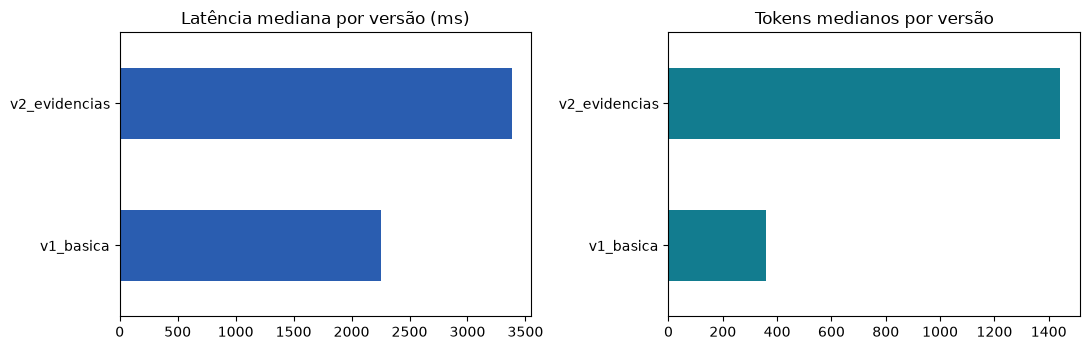

Amostra pequena: use este gráfico para orientar a leitura do dashboard, não para concluir.


In [27]:
"""Pré-visualização local. O gráfico definitivo é o do dashboard do LangSmith."""

import matplotlib.pyplot as plt

agregado = (
    df_execucoes.groupby("agent_version")[["latencia_ms", "tokens_total"]]
    .median()
    .reindex(VERSOES_AGENTE)
)

figura, eixos = plt.subplots(1, 2, figsize=(11, 3.6))
agregado["latencia_ms"].plot(kind="barh", ax=eixos[0], color="#2a5db0")
eixos[0].set_title("Latência mediana por versão (ms)")
eixos[0].set_ylabel("")
agregado["tokens_total"].plot(kind="barh", ax=eixos[1], color="#127c8f")
eixos[1].set_title("Tokens medianos por versão")
eixos[1].set_ylabel("")
figura.tight_layout()
plt.show()

print("Amostra pequena: use este gráfico para orientar a leitura do dashboard, não para concluir.")

<div class="cf-bloco cf-reflexao" style="background:#fff4e0;color:#3a2c05;border-left:6px solid #c98a00;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;font-size:15px;letter-spacing:0.3px;color:#3a2c05;">REFLEXÃO</p>
<p>Olhando a tabela e o gráfico acima:</p>
<ol style="margin:8px 0 0 18px;">
<li>A versão mais rápida também é a melhor?</li>
<li>O custo adicional em tokens da versão B trouxe ganho real — ou apenas texto mais longo?</li>
<li>Com seis execuções por versão, quais dessas afirmações você conseguiria defender diante de uma
equipe de produto, e quais ainda são impressão?</li>
</ol>
</div>

---

## 12. DASHBOARDS ORIENTADOS A PERGUNTAS

<div class="cf-bloco cf-reflexao" style="background:#fff4e0;color:#3a2c05;border-left:6px solid #c98a00;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;font-size:15px;letter-spacing:0.3px;color:#3a2c05;">PERGUNTA OPERACIONAL</p><p>Um dashboard sem pergunta é decoração. Qual decisão você precisa tomar ao abrir este painel?</p>
</div>

### Conceito

Um gráfico só vale se alguém puder agir a partir dele. Antes de criar qualquer chart, escreva a pergunta
e a ação correspondente. Se não existir ação possível, o gráfico não precisa existir.

### Parte 1 — Dashboard predefinido do projeto

O LangSmith gera automaticamente um painel para cada projeto de tracing. Abra-o e percorra os cartões
na ordem abaixo.
<div class="cf-bloco cf-checkpoint" style="background:#e7f7ef;color:#0d2b1e;border-left:6px solid #1e8e5a;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;font-size:15px;letter-spacing:0.3px;color:#0d2b1e;">ROTEIRO NO DASHBOARD PREDEFINIDO</p>
<p><strong>Local:</strong> Projects → projeto da aula → aba <strong>Dashboard</strong>.</p>
<table style="width:100%;border-collapse:collapse;font-size:14px;">
<tr style="font-weight:700;"><td style="padding:6px 10px 6px 0;">Cartão</td><td style="padding:6px 0;">O que observar e por que importa</td></tr>
<tr><td style="padding:6px 10px 6px 0;vertical-align:top;border-top:1px solid rgba(13,43,30,0.2);"><strong>Trace count</strong></td>
<td style="padding:6px 0;border-top:1px solid rgba(13,43,30,0.2);">Volume de execuções. Confirma se a amostra é grande o bastante para qualquer conclusão. Com poucas dezenas de runs, medianas ainda oscilam muito.</td></tr>
<tr><td style="padding:6px 10px 6px 0;vertical-align:top;border-top:1px solid rgba(13,43,30,0.2);"><strong>Error rate</strong></td>
<td style="padding:6px 0;border-top:1px solid rgba(13,43,30,0.2);">Saúde técnica pura. Taxa zero <em>não</em> significa qualidade — significa apenas ausência de exceção.</td></tr>
<tr><td style="padding:6px 10px 6px 0;vertical-align:top;border-top:1px solid rgba(13,43,30,0.2);"><strong>Latency</strong> (p50 e p99)</td>
<td style="padding:6px 0;border-top:1px solid rgba(13,43,30,0.2);">A mediana descreve o dia normal; o p99 descreve a experiência do usuário mais prejudicado. O cenário de catálogo lento deve aparecer na cauda, não no centro.</td></tr>
<tr><td style="padding:6px 10px 6px 0;vertical-align:top;border-top:1px solid rgba(13,43,30,0.2);"><strong>LLM calls</strong></td>
<td style="padding:6px 0;border-top:1px solid rgba(13,43,30,0.2);">Deve haver uma chamada principal por execução. Um número maior indica repetição, retry silencioso ou laço inesperado.</td></tr>
<tr><td style="padding:6px 10px 6px 0;vertical-align:top;border-top:1px solid rgba(13,43,30,0.2);"><strong>Tokens</strong></td>
<td style="padding:6px 0;border-top:1px solid rgba(13,43,30,0.2);">Proxy direto de custo e de tamanho de contexto. Crescimento sem ganho de qualidade é desperdício.</td></tr>
<tr><td style="padding:6px 10px 6px 0;vertical-align:top;border-top:1px solid rgba(13,43,30,0.2);"><strong>Cost</strong></td>
<td style="padding:6px 0;border-top:1px solid rgba(13,43,30,0.2);">Aparece quando o modelo tem preço conhecido pela plataforma. Se estiver vazio, use tokens — e não estime valores.</td></tr>
<tr><td style="padding:6px 10px 6px 0;vertical-align:top;border-top:1px solid rgba(13,43,30,0.2);"><strong>Tools</strong></td>
<td style="padding:6px 0;border-top:1px solid rgba(13,43,30,0.2);">Contagem e duração por ferramenta. É onde a degradação de dependência externa aparece antes de virar reclamação.</td></tr>
<tr><td style="padding:6px 10px 6px 0;vertical-align:top;border-top:1px solid rgba(13,43,30,0.2);"><strong>Feedback scores</strong></td>
<td style="padding:6px 0;border-top:1px solid rgba(13,43,30,0.2);">A única série do painel que fala de qualidade semântica. Vai ser preenchida na seção 15.</td></tr>
</table>
</div>

### Perguntas a responder com o painel aberto

1. Qual versão é mais lenta — e a diferença é consistente ou vem de um único cenário?
2. Qual versão usa mais tokens, e qual é a razão entre elas?
3. Qual cenário concentra latência?
4. Existe diferença de qualidade entre as versões, ou só de tamanho de resposta?
5. O ganho de qualidade compensa o custo e o tempo adicionais?

<div class="cf-bloco cf-avaliacao" style="background:#e8f6f9;color:#0f2b31;border-left:6px solid #127c8f;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0;">Anote as respostas com os números que você viu. Nenhum resultado é fornecido por este notebook:
os valores dependem do modelo configurado, da rede e do momento da execução.</p>
</div>

### Parte 2 — Roteiro do dashboard personalizado

Crie um dashboard novo no projeto e adicione os charts abaixo. Para cada um: a pergunta que ele responde,
como configurá-lo e a ação que ele habilita.

| # | Chart | Configuração | Pergunta | Ação habilitada |
|---|---|---|---|---|
| 1 | Latência por `agent_version` | métrica Latency (p50 e p99), agrupado por metadata `agent_version` | A versão B custa mais tempo? | decidir se o ganho justifica o atraso |
| 2 | Tokens por `agent_version` | métrica Total tokens, agrupado por metadata `agent_version` | Quanto contexto extra a versão B consome? | dimensionar custo antes de escalar |
| 3 | Latência por `scenario_type` | métrica Latency, agrupado por metadata `scenario_type` | Qual situação concentra lentidão? | priorizar otimização de ferramenta |
| 4 | `quality_score` por versão | métrica Feedback score, chave `quality_score`, agrupado por `agent_version` | A versão B é semanticamente melhor? | promover ou descartar a versão |
| 5 | Taxa de conformidade com política | métrica Feedback score, chave `policy_compliance`, agrupado por `scenario_type` | Onde o agente desobedece a regra? | endurecer prompt ou política |
| 6 | Chamadas de ferramenta por cenário | contagem de runs filtrada por nome `tool.*`, agrupada por `scenario_type` | Alguma ferramenta é chamada mais do que deveria? | detectar retry ou laço |

<div class="cf-bloco cf-conceito" style="background:#eaf1fd;color:#11223d;border-left:6px solid #2a5db0;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0;">Repare que os charts 1–3 são <strong>saúde técnica</strong> e os charts 4–5 são <strong>qualidade
semântica</strong>. Um dashboard que só tem os três primeiros é incapaz de detectar a combinação B da seção 5.</p>
</div>

---

## 13. ALERTAS ACIONÁVEIS NO LANGSMITH

<div class="cf-bloco cf-reflexao" style="background:#fff4e0;color:#3a2c05;border-left:6px solid #c98a00;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;font-size:15px;letter-spacing:0.3px;color:#3a2c05;">PERGUNTA OPERACIONAL</p><p>Quando este alerta disparar às três da manhã, a pessoa de plantão vai saber o que fazer?</p>
</div>

### Conceito

Um alerta acionável tem seis elementos. Sem eles, o alerta vira ruído e acaba silenciado:

| Elemento | Pergunta | Exemplo no CopaFigurinhas |
|---|---|---|
| **Sintoma** | O que foi observado? | latência p99 do run raiz acima do limiar |
| **Contexto** | Onde e em quais condições? | projeto da aula, `scenario_type=catalogo_lento` |
| **Impacto** | Quem é afetado e como? | usuário espera a resposta da troca; abandono aumenta |
| **Evidência** | O que prova o sintoma? | trace com `tool.consultar_catalogo` dominando a duração |
| **Responsável** | Quem age? | quem mantém a integração de catálogo |
| **Próxima ação** | O que fazer primeiro? | verificar a dependência de catálogo; se persistir, degradar com cache |

A célula abaixo calcula os limiares **a partir das execuções reais** desta sessão. Não use números de
outra turma: o limiar depende do seu ambiente.

In [29]:
"""Limiares sugeridos a partir das execuções observadas nesta sessão."""


def limiares_observados(df: pd.DataFrame) -> pd.DataFrame:
    """Deriva referências de alerta dos dados reais coletados."""
    if df.empty:
        raise ValueError(
            "Nenhuma execução registrada. Rode a bateria da seção 11 antes de definir limiares."
        )
    latencias = sorted(df["latencia_ms"].tolist())
    mediana = statistics.median(latencias)
    maximo = max(latencias)
    linhas = [
        {"referência": "latência mediana observada", "valor_ms": round(mediana, 1)},
        {"referência": "latência máxima observada", "valor_ms": round(maximo, 1)},
        {
            "referência": "limiar sugerido (2x a mediana)",
            "valor_ms": round(mediana * 2, 1),
        },
        {
            "referência": "limiar sugerido (mediana + 50%)",
            "valor_ms": round(mediana * 1.5, 1),
        },
    ]
    return pd.DataFrame(linhas).set_index("referência")


display(limiares_observados(df_execucoes))
print(
    "Escolha o limiar sabendo que o cenário de catálogo lento é intencional: "
    "um limiar abaixo dele vai disparar todo dia sem indicar problema novo."
)

,valor_ms
referência,
latência mediana observada,3185.1
latência máxima observada,8169.3
limiar sugerido (2x a mediana),6370.3
limiar sugerido (mediana + 50%),4777.7


Escolha o limiar sabendo que o cenário de catálogo lento é intencional: um limiar abaixo dele vai disparar todo dia sem indicar problema novo.


### Especificações para configuração manual

Configure os três alertas abaixo em **Projects → projeto da aula → Alerts → New alert**.
Nenhum deles depende de disparar durante a aula: a especificação é o entregável.

<div class="cf-bloco cf-seguranca" style="background:#fdeaea;color:#3d1414;border-left:6px solid #c0392b;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 6px 0;font-weight:700;">ALERTA 1 — DEGRADAÇÃO DE LATÊNCIA</p>
<ul style="margin:6px 0 0 18px;">
<li><strong>Métrica:</strong> Latency</li>
<li><strong>Filtro:</strong> run raiz <code>copafigurinhas.run</code> no projeto da aula</li>
<li><strong>Condição:</strong> p99 acima do limiar que você derivou na célula anterior, sustentado por uma janela de observação (evita disparo por pico isolado)</li>
<li><strong>Objetivo:</strong> detectar degradação antes que ela vire reclamação de usuário</li>
<li><strong>Sintoma:</strong> tempo de resposta acima do normal — <strong>Contexto:</strong> projeto e cenário identificados pelos metadados — <strong>Impacto:</strong> usuário espera mais para saber se pode trocar — <strong>Evidência:</strong> trace com a etapa dominante — <strong>Responsável:</strong> manutenção da integração de catálogo — <strong>Próxima ação:</strong> abrir o trace mais lento e comparar a duração da ferramenta com a do modelo</li>
</ul>
</div>

<div class="cf-bloco cf-seguranca" style="background:#fdeaea;color:#3d1414;border-left:6px solid #c0392b;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 6px 0;font-weight:700;">ALERTA 2 — FALHA DE EXECUÇÃO</p>
<ul style="margin:6px 0 0 18px;">
<li><strong>Métrica:</strong> Errors</li>
<li><strong>Filtro:</strong> projeto da aula; opcionalmente restrito a runs de ferramenta (<code>tool.*</code>) para separar falha de dependência de falha de agente</li>
<li><strong>Condição:</strong> qualquer erro, ou taxa de erro acima de um percentual mínimo em uma janela</li>
<li><strong>Objetivo:</strong> detectar falhas do agente ou das ferramentas</li>
<li><strong>Sintoma:</strong> runs com status de erro — <strong>Contexto:</strong> qual nó ou ferramenta falhou — <strong>Impacto:</strong> nenhuma recomendação é entregue — <strong>Evidência:</strong> stack trace no run filho — <strong>Responsável:</strong> quem mantém o componente que falhou — <strong>Próxima ação:</strong> reproduzir o caso pelo <code>case_id</code> registrado nos metadados</li>
</ul>
</div>

<div class="cf-bloco cf-seguranca" style="background:#fdeaea;color:#3d1414;border-left:6px solid #c0392b;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 6px 0;font-weight:700;">ALERTA 3 — REGRESSÃO DE QUALIDADE</p>
<ul style="margin:6px 0 0 18px;">
<li><strong>Métrica:</strong> Feedback Score</li>
<li><strong>Chave:</strong> <code>quality_score</code> ou <code>policy_compliance</code></li>
<li><strong>Condição:</strong> média abaixo do patamar aceitável na janela, ou queda relativa em relação ao período anterior</li>
<li><strong>Objetivo:</strong> detectar regressão semântica — o caso em que tudo continua verde e a resposta piora</li>
<li><strong>Sintoma:</strong> queda do score — <strong>Contexto:</strong> versão e cenário pelos metadados — <strong>Impacto:</strong> recomendações mal fundamentadas chegam ao usuário — <strong>Evidência:</strong> traces com feedback baixo — <strong>Responsável:</strong> quem mantém o prompt e a política — <strong>Próxima ação:</strong> adicionar os casos ruins ao dataset offline e rodar um experimento antes de qualquer mudança</li>
</ul>
</div>

<div class="cf-bloco cf-conceito" style="background:#eaf1fd;color:#11223d;border-left:6px solid #2a5db0;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0;">Os alertas 1 e 2 vigiam <strong>saúde técnica</strong>. Só o alerta 3 vigia <strong>qualidade
semântica</strong> — e ele só funciona se existir feedback registrado com chave consistente. É por isso que a
próxima seção existe.</p>
</div>

---

## 14. PRIVACIDADE E SEGURANÇA DOS TRACES

<div class="cf-bloco cf-reflexao" style="background:#fff4e0;color:#3a2c05;border-left:6px solid #c98a00;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;font-size:15px;letter-spacing:0.3px;color:#3a2c05;">PERGUNTA OPERACIONAL</p><p>O que deste pedido você aceitaria que ficasse pesquisável por qualquer pessoa com acesso ao workspace?</p>
</div>

<div class="cf-bloco cf-seguranca" style="background:#fdeaea;color:#3d1414;border-left:6px solid #c0392b;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:16px;">
<p style="margin:0;font-weight:700;">Tudo que é enviado ao tracing pode tornar-se pesquisável por usuários
autorizados do workspace.</p>
</div>

### Conceito

Seis controles, aplicados em camadas:

- **Minimização** — não enviar o que não é necessário para investigar. É o controle mais barato e o mais esquecido.
- **Mascaramento** — transformar o dado antes do envio, preservando a estrutura e destruindo o conteúdo sensível.
- **Controle de acesso** — quem pode ler o projeto. Tracing não é log de aplicação: ele guarda entradas e saídas completas.
- **Retenção** — por quanto tempo o dado fica disponível. Trace eterno é passivo, não é ativo.
- **Rastreamento condicional** — amostrar ou desligar tracing em fluxos que lidam com dado sensível.
- **Ambientes separados** — projeto de aula, de desenvolvimento e de produção nunca compartilham o mesmo espaço.

Todos os dados deste notebook são fictícios: os usuários são identificadores inventados e os e-mails usam
o domínio reservado `.invalido`, que não existe na internet. Ainda assim, vamos mascarar — porque o hábito
é o que protege quando o dado for real.

In [30]:
"""Mascaramento de dados sensíveis antes do envio ao tracing."""

import re

PADRAO_EMAIL = re.compile(r"[\w\.\-\+]+@[\w\.\-]+")
PADRAO_USUARIO = re.compile(r"usr_[a-z]+_\d+")
PADRAO_INTERNO = re.compile(r"\bINT-\d{4,}\b")


def mascarar_texto(valor: str) -> str:
    """Oculta e-mail, identificador de usuário e identificador interno."""
    valor = PADRAO_EMAIL.sub("[email_mascarado]", valor)
    valor = PADRAO_USUARIO.sub("[usuario_mascarado]", valor)
    valor = PADRAO_INTERNO.sub("[id_interno_mascarado]", valor)
    return valor


CAMPOS_SENSIVEIS = {"email_ficticio", "apelido", "observacao_livre"}


def mascarar_valor(chave: str, valor: Any) -> Any:
    if chave in CAMPOS_SENSIVEIS:
        return "[mascarado]"
    if isinstance(valor, str):
        return mascarar_texto(valor)
    if isinstance(valor, dict):
        return {k: mascarar_valor(k, v) for k, v in valor.items()}
    if isinstance(valor, list):
        return [mascarar_valor(chave, item) for item in valor]
    return valor


def mascarar_dicionario(dados: dict[str, Any]) -> dict[str, Any]:
    """Aplica o mascaramento preservando a estrutura observável."""
    return {chave: mascarar_valor(chave, valor) for chave, valor in dados.items()}


pedido_sensivel = {
    "usuario_id": "usr_aurora_01",
    "email_ficticio": "colecionador.aurora@exemplo.invalido",
    "identificador_interno": "INT-948271",
    "observacao_livre": "Meu vizinho do 402 disse que a 425 vale mais.",
    "pedido": (
        "Sou o usr_aurora_01 (colecionador.aurora@exemplo.invalido, ticket INT-948271). "
        "Ofereço duas 112 e uma 208 pela 417."
    ),
    "oferecidas": {"112": 2, "208": 1},
    "solicitadas": {"417": 1},
}

print("ANTES do mascaramento:")
for chave, valor in pedido_sensivel.items():
    print(f"  {chave}: {valor}")

print("\nDEPOIS do mascaramento:")
for chave, valor in mascarar_dicionario(pedido_sensivel).items():
    print(f"  {chave}: {valor}")

ANTES do mascaramento:
  usuario_id: usr_aurora_01
  email_ficticio: colecionador.aurora@exemplo.invalido
  identificador_interno: INT-948271
  observacao_livre: Meu vizinho do 402 disse que a 425 vale mais.
  pedido: Sou o usr_aurora_01 (colecionador.aurora@exemplo.invalido, ticket INT-948271). Ofereço duas 112 e uma 208 pela 417.
  oferecidas: {'112': 2, '208': 1}
  solicitadas: {'417': 1}

DEPOIS do mascaramento:
  usuario_id: [usuario_mascarado]
  email_ficticio: [mascarado]
  identificador_interno: [id_interno_mascarado]
  observacao_livre: [mascarado]
  pedido: Sou o [usuario_mascarado] ([email_mascarado], ticket [id_interno_mascarado]). Ofereço duas 112 e uma 208 pela 417.
  oferecidas: {'112': 2, '208': 1}
  solicitadas: {'417': 1}


In [31]:
"""Trace de demonstração com entradas e saídas mascaradas.

Usa process_inputs / process_outputs do @traceable — mecanismo documentado e compatível
com a versão instalada do SDK. Esta demonstração é determinística e não chama a LLM.
"""


def _mascarar_entradas(entradas: dict[str, Any]) -> dict[str, Any]:
    return {chave: mascarar_valor(chave, valor) for chave, valor in entradas.items()}


def _mascarar_saidas(saidas: dict[str, Any]) -> dict[str, Any]:
    return mascarar_dicionario(saidas)


@traceable(
    run_type="chain",
    name="copafigurinhas.demo_privacidade",
    process_inputs=_mascarar_entradas,
    process_outputs=_mascarar_saidas,
)
def analisar_com_mascaramento(pedido: dict[str, Any]) -> dict[str, Any]:
    """Roda a parte determinística do fluxo sobre um pedido com dados sensíveis."""
    album = consultar_album(pedido["usuario_id"])
    codigos = list(pedido["oferecidas"]) + list(pedido["solicitadas"])
    catalogo = consultar_catalogo(codigos)
    inventario = validar_posse_e_duplicidade(album, pedido["oferecidas"])
    equidade = avaliar_equidade_da_troca(
        pedido["oferecidas"], pedido["solicitadas"], catalogo
    )
    return {
        "usuario_id": pedido["usuario_id"],
        "email_ficticio": pedido["email_ficticio"],
        "resumo_pedido": pedido["pedido"],
        "inventario_ok": inventario["ok"],
        "diferenca_percentual": equidade["diferenca_percentual"],
        "troca_justa": equidade["troca_justa"],
        "risco": equidade["risco"],
    }


exigir_envio_langsmith()

with tracing_context(enabled=True, project_name=LANGSMITH_PROJECT):
    saida_mascarada = analisar_com_mascaramento(
        pedido_sensivel,
        langsmith_extra={
            "client": cliente_langsmith(),
            "tags": [*TAGS_BASE, "privacidade"],
            "metadata": {
                "session_id": SESSION_ID,
                "environment": "aula",
                "lesson_phase": "14_privacidade",
                "dado_mascarado": True,
            },
        },
    )

wait_for_all_tracers()
cliente_langsmith().flush()
CONTADOR["traces_enviados"] += 1

print("Saída local (não mascarada, permanece apenas na sua máquina):")
for chave, valor in saida_mascarada.items():
    print(f"  {chave}: {valor}")
print()
print("No LangSmith, o run copafigurinhas.demo_privacidade mostra a versão mascarada.")

Saída local (não mascarada, permanece apenas na sua máquina):
  usuario_id: usr_aurora_01
  email_ficticio: colecionador.aurora@exemplo.invalido
  resumo_pedido: Sou o usr_aurora_01 (colecionador.aurora@exemplo.invalido, ticket INT-948271). Ofereço duas 112 e uma 208 pela 417.
  inventario_ok: True
  diferenca_percentual: 14.29
  troca_justa: True
  risco: baixo

No LangSmith, o run copafigurinhas.demo_privacidade mostra a versão mascarada.


### Alternativa: mascarar no cliente inteiro

Quando a regra vale para **toda** a aplicação, e não apenas para uma função, o mascaramento pode ser
declarado na construção do cliente:

```python
cliente_restrito = Client(
    api_key=LANGSMITH_API_KEY,
    hide_inputs=mascarar_dicionario,    # ou True, para ocultar tudo
    hide_outputs=mascarar_dicionario,
    hide_metadata=True,
)
```

Escolha a camada de acordo com o alcance da regra: `process_inputs`/`process_outputs` para um ponto
específico do fluxo; `hide_inputs`/`hide_outputs`/`hide_metadata` para toda a aplicação.
<div class="cf-bloco cf-langsmith" style="background:#f1ecfd;color:#241b3d;border-left:6px solid #6b3fd4;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;font-size:15px;letter-spacing:0.3px;color:#241b3d;">ROTEIRO NO LANGSMITH</p>
<table style='width:100%;border-collapse:collapse;font-size:14px;'>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>Objetivo</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'>Confirmar que o dado sensível não chegou ao servidor e que a investigação continua possível.</td></tr>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>Local na interface</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'>Projects → projeto da aula → run <code>copafigurinhas.demo_privacidade</code>.</td></tr>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>Filtro</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'><code>Tag is privacidade</code> ou <code>Metadata lesson_phase is 14_privacidade</code>.</td></tr>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>O que observar</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'>Nos <strong>Inputs</strong>: o e-mail, o identificador de usuário e o ticket interno devem aparecer substituídos. Nos <strong>Outputs</strong>: idem. O que <strong>permanece</strong> visível: códigos de figurinha, diferença percentual, resultado do inventário, risco e a árvore de ferramentas.</td></tr>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>Por que importa</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'>O trace continua servindo para investigar — dá para saber que a troca foi analisada, por quais ferramentas passou e qual foi o veredito — sem carregar dado pessoal.</td></tr>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>O que pode ser concluido</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'>Que o mascaramento preserva a capacidade de diagnóstico técnico.</td></tr>
<tr><td style='padding:6px 10px 6px 0;vertical-align:top;white-space:nowrap;font-weight:700;border-bottom:1px solid rgba(36,27,61,0.18);'>O que ainda nao pode ser concluido</td><td style='padding:6px 0;vertical-align:top;border-bottom:1px solid rgba(36,27,61,0.18);'>Que o sistema está em conformidade. Mascaramento é um controle entre seis; retenção e controle de acesso não são verificáveis neste trace.</td></tr>
</table>
<p style='margin:12px 0 0 0;'><strong>Reflexão:</strong> Se você mascarasse também os códigos das figurinhas e os valores, ainda conseguiria explicar por que a troca foi bloqueada? Onde fica o ponto de equilíbrio entre risco e capacidade de investigar?</p>
</div>

<div class="cf-bloco cf-seguranca" style="background:#fdeaea;color:#3d1414;border-left:6px solid #c0392b;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0;"><strong>Esconder tudo</strong> reduz a capacidade de investigação a quase zero: sem inputs e
outputs, um trace vira um cronômetro. <strong>Registrar tudo</strong> cria risco permanente: o dado fica
pesquisável, replicado e sujeito a acesso de quem entrar no workspace depois de você.
A decisão não é técnica, é de risco — e precisa ser explícita.</p>
</div>

---

## 15. LLM COMO AVALIADOR

<div class="cf-bloco cf-reflexao" style="background:#fff4e0;color:#3a2c05;border-left:6px solid #c98a00;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;font-size:15px;letter-spacing:0.3px;color:#3a2c05;">PERGUNTA OPERACIONAL</p><p>O que sobra para avaliar depois que todas as regras determinísticas já foram checadas?</p>
</div>

### Conceito

Sobra o que é linguagem: se a explicação é **clara**, se é **útil** para quem vai decidir, se a
**justificativa** sustenta a conclusão, se a resposta está **fundamentada** nos dados e se ela
**trata a incerteza** com honestidade. Nada disso é verificável por `if`.

Regras deste juiz:

- **Rubrica explícita de 1 a 5** — sem rubrica, a nota é ruído.
- **Saída estruturada** — nota por critério, não um parágrafo livre.
- **Entrada mínima** — o juiz recebe pedido, resposta, evidências, política e rubrica. Ele **não** recebe
  raciocínio interno (chain-of-thought), segredos, chaves ou dados que não afetam o julgamento.
- **Limite de execução** — no máximo `MAX_CASOS_JUDGE` casos.

In [37]:
"""Juiz LLM com rubrica explícita e saída estruturada."""

RUBRICA = """
Escala de 1 a 5 para cada critério:
5 = exemplar: preciso, completo e verificável contra os dados fornecidos.
4 = bom: correto, com pequena imprecisão ou omissão sem impacto na decisão.
3 = aceitável: conclusão defensável, mas fundamentação fraca ou genérica.
2 = fraco: afirmação relevante sem suporte nos dados fornecidos.
1 = inaceitável: contradiz os dados, inventa informação ou não responde ao pedido.

Critérios:
- clareza: a explicação é compreensível por quem não conhece o sistema.
- utilidade: ajuda quem precisa decidir sobre a troca.
- qualidade_justificativa: o raciocínio apresentado sustenta a conclusão.
- fundamentacao: as afirmações são rastreáveis aos dados fornecidos.
- tratamento_incerteza: o que não pode ser afirmado é declarado como tal.
"""


class NotaDoJuiz(BaseModel):
    clareza: int = Field(ge=1, le=5)
    utilidade: int = Field(ge=1, le=5)
    qualidade_justificativa: int = Field(ge=1, le=5)
    fundamentacao: int = Field(ge=1, le=5)
    tratamento_incerteza: int = Field(ge=1, le=5)
    comentario: str = Field(min_length=1, description="Uma frase justificando as notas.")


PROMPT_JUIZ = (
    "Você avalia respostas de um agente de trocas de figurinhas.\n"
    "Julgue APENAS com base no material fornecido. Não invente fatos e não presuma "
    "informação ausente.\n"
    "Aplique a rubrica de forma estrita: uma resposta sem evidência verificável não "
    "pode receber nota alta em fundamentacao.\n"
    f"{RUBRICA}"
)


def julgar_resposta(
    cenario: Cenario,
    resposta: dict[str, Any],
    *,
    metadados: dict[str, Any],
    enviar_trace: bool | None = None,
) -> NotaDoJuiz:
    """Aplica a rubrica a uma resposta. Recebe apenas o material necessário."""
    exigir_chamadas_reais()
    exigir_juiz()

    material = (
        f"PEDIDO DO USUÁRIO:\n{cenario.pedido}\n\n"
        f"RESPOSTA DO AGENTE:\n"
        f"- recomendação: {resposta['recomendacao']}\n"
        f"- justificativa: {resposta['justificativa']}\n"
        f"- incerteza declarada: {resposta['incerteza'] or '(nenhuma)'}\n\n"
        f"EVIDÊNCIAS APRESENTADAS:\n{resposta['evidencias_utilizadas'] or '(nenhuma)'}\n\n"
        f"POLÍTICA APLICADA:\n"
        f"- status: {resposta['status_politica']}\n"
        f"- regras violadas: {resposta['regras_violadas'] or '(nenhuma)'}\n"
        f"- regras vigentes: {REGRAS_POLITICA}"
    )

    juiz = construir_llm(MODELO_JUIZ, max_tokens=MAX_OUTPUT_TOKENS)
    cadeia = juiz.with_structured_output(
        NotaDoJuiz, method="json_schema", include_raw=True
    )
    configuracao = {
        "run_name": "judge.avaliar_resposta",
        "tags": [*TAGS_BASE, "judge"],
        "metadata": {"modelo_juiz": MODELO_JUIZ, "environment": "aula", **metadados},
    }

    if enviar_trace is None:
        bruto = cadeia.invoke(
            [("system", PROMPT_JUIZ), ("human", material)], config=configuracao
        )
    else:
        with tracing_context(enabled=enviar_trace, project_name=LANGSMITH_PROJECT):
            bruto = cadeia.invoke(
                [("system", PROMPT_JUIZ), ("human", material)], config=configuracao
            )
    CONTADOR["llm_juiz"] += 1

    nota = bruto["parsed"]
    if nota is None:
        raise ValueError(
            "O juiz não retornou uma avaliação estruturada válida. Nenhuma nota será "
            f"inventada. Erro de parsing: {bruto.get('parsing_error')!r}."
        )
    return nota


def media_das_notas(nota: NotaDoJuiz) -> float:
    return round(
        statistics.mean(
            [
                nota.clareza,
                nota.utilidade,
                nota.qualidade_justificativa,
                nota.fundamentacao,
                nota.tratamento_incerteza,
            ]
        ),
        2,
    )


def avaliar_com_juiz(resultado: dict[str, Any]) -> dict[str, Any]:
    """Executa o juiz sobre uma execução já registrada nesta sessão."""
    cenario = CENARIOS_POR_ID[resultado["case_id"]]
    nota = julgar_resposta(
        cenario,
        resultado["resposta"],
        metadados={
            "case_id": resultado["case_id"],
            "session_id": SESSION_ID,
            "agent_version": resultado["agent_version"],
            "scenario_type": resultado["scenario_type"],
            "lesson_phase": "17_judge",
            "run_avaliado": resultado["run_id"],
        },
        enviar_trace=AUTORIZAR_ENVIO_LANGSMITH,
    )
    return {
        "case_id": resultado["case_id"],
        "agent_version": resultado["agent_version"],
        "run_avaliado": resultado["run_id"],
        "notas": nota.model_dump(),
        "media": media_das_notas(nota),
    }


print(f"Juiz configurado com {MODELO_JUIZ}. Limite: {MAX_CASOS_JUDGE} casos.")

Juiz configurado com gpt-5-mini. Limite: 3 casos.


In [38]:
"""Execução do juiz em até MAX_CASOS_JUDGE casos, escolhidos por relevância."""

# Prioriza os casos em que o julgamento semântico agrega mais: caminho feliz (para
# comparar as duas versões) e o caso crítico que exige aprovação humana.
prioridade_judge = [
    ("cf-001", "v1_basica"),
    ("cf-001", "v2_evidencias"),
    ("cf-006", "v2_evidencias"),
]

selecionados = [
    execucao
    for case_id, versao in prioridade_judge
    if (execucao := ja_executado(case_id, versao)) is not None
][:MAX_CASOS_JUDGE]

print(f"Casos selecionados para o juiz: {len(selecionados)} (limite {MAX_CASOS_JUDGE})")
print(f"Chamadas de juiz previstas: {len(selecionados)} — modelo {MODELO_JUIZ}")
if len(selecionados) > MAX_CASOS_JUDGE:
    raise ValueError("Seleção excede MAX_CASOS_JUDGE.")

avaliacoes_juiz: list[dict[str, Any]] = []
for execucao in selecionados:
    avaliacao = avaliar_com_juiz(execucao)
    avaliacoes_juiz.append(avaliacao)
    print(
        f"  {avaliacao['case_id']}/{avaliacao['agent_version']}: "
        f"média {avaliacao['media']} — {avaliacao['notas']['comentario']}"
    )

    # A nota do juiz também vira feedback pesquisável, com chave própria.
    if AUTORIZAR_ENVIO_LANGSMITH and execucao["trace_enviado"]:
        cliente_langsmith().create_feedback(
            run_id=execucao["run_id"],
            key="judge_media",
            score=avaliacao["media"] / 5.0,
            comment=avaliacao["notas"]["comentario"],
        )
    else:
        print("    (feedback do juiz não enviado: execução sem trace no LangSmith)")

if AUTORIZAR_ENVIO_LANGSMITH:
    cliente_langsmith().flush()

display(
    pd.DataFrame(
        [
            {"case_id": a["case_id"], "agent_version": a["agent_version"],
             "média": a["media"], **a["notas"]}
            for a in avaliacoes_juiz
        ]
    ).set_index(["case_id", "agent_version"])
)
print(f"\nChamadas de juiz realizadas: {CONTADOR['llm_juiz']}")

Casos selecionados para o juiz: 3 (limite 3)
Chamadas de juiz previstas: 3 — modelo gpt-5-mini
  cf-001/v1_basica: média 3 — Resposta clara e com recomendações práticas, mas justificativa é genérica e não cita evidências do caso (por exemplo raridades/valores de 112,208,417) nem aplica as regras fornecidas (como diferença de valor >20%). Não declarou incertezas específicas nem usou os dados apresentados (nenhum).
  cf-001/v2_evidencias: média 5 — Resposta clara e útil: apresenta recomendação direta, calcula valores com dados do catálogo e mostra diferença percentual comparada ao limite; indica saldos e duplicatas. Incertezas relevantes (condição física, promoções) foram explicitadas. Todas as afirmações são rastreáveis às evidências fornecidas.
  cf-006/v2_evidencias: média 5 — Resposta clara e útil: conclui por revisão humana citando diferença de valor dentro do limite e indicando que ambas as políticas POL-005 e POL-006 exigem confirmação; todas as afirmações estão diretamente rastre

média  clareza  utilidade  qualidade_justificativa  \
case_id agent_version                                                       
cf-001  v1_basica          3        4          4                        3   
        v2_evidencias      5        5          5                        5   
cf-006  v2_evidencias      5        5          5                        5   

                       fundamentacao  tratamento_incerteza  \
case_id agent_version                                        
cf-001  v1_basica                  2                     2   
        v2_evidencias              5                     5   
cf-006  v2_evidencias              5                     5   

                                                              comentario  
case_id agent_version                                                     
cf-001  v1_basica      Resposta clara e com recomendações práticas, m...  
        v2_evidencias  Resposta clara e útil: apresenta recomendação ...  
cf-006  v2_evidencias  Resposta clara e útil: conclui por revisão hum...


Chamadas de juiz realizadas: 3


<div class="cf-bloco cf-avaliacao" style="background:#e8f6f9;color:#0f2b31;border-left:6px solid #127c8f;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0 0 8px 0;font-weight:700;font-size:15px;letter-spacing:0.3px;color:#0f2b31;">LIMITAÇÕES DO JUIZ LLM</p>
<ul style="margin:6px 0 0 18px;">
<li><strong>Custo</strong> — cada avaliação é uma chamada paga. Avaliar todo o tráfego com juiz costuma custar
mais que produzir as respostas.</li>
<li><strong>Variabilidade</strong> — a mesma resposta pode receber notas diferentes em execuções diferentes.
Trate a nota como sinal agregado, nunca como veredito individual.</li>
<li><strong>Viés</strong> — juízes tendem a premiar respostas longas, bem formatadas e escritas no estilo do
próprio modelo, mesmo quando a resposta curta está mais correta.</li>
<li><strong>Necessidade de rubrica</strong> — sem critérios explícitos, a nota mede a preferência do modelo,
não a qualidade do agente.</li>
<li><strong>Necessidade de avaliação humana</strong> — em casos críticos (aqui, as trocas com figurinha
lendária), a decisão continua sendo de uma pessoa. O juiz prioriza a fila; ele não a resolve.</li>
</ul>
<p style="margin:10px 0 0 0;"><strong>Reflexão:</strong> compare a nota do juiz com o
<code>quality_score</code> determinístico do mesmo caso. Se divergirem, qual dos dois você levaria
para uma reunião de decisão — e por quê?</p>
</div>

<details>
<summary style="cursor:pointer;font-weight:700;font-size:16px;padding:10px 14px;background:#efefef;color:#1c1c1c;border-left:6px solid #3f3f3f;border-radius:8px;">
Análise de referência (abra somente depois de preencher a sua)
</summary>

<div style="background:#f7f7f7;color:#1c1c1c;border-left:6px solid #3f3f3f;border-radius:8px;padding:16px 18px;margin:10px 0;line-height:1.65;font-size:15px;">

<p><strong>Raciocínio esperado — sem depender de nenhum identificador fixo.</strong></p>

<p><strong>1. Separar as duas perguntas antes de olhar os dados.</strong> "Executou bem?" e "respondeu bem?"
têm evidências diferentes: a primeira sai de latência, erro e duração por etapa; a segunda sai de
feedback, avaliadores e do conteúdo da resposta. Misturar as duas é o erro mais comum — leva a
"otimizar" um problema semântico trocando de modelo.</p>

<p><strong>2. A anomalia técnica.</strong> O caso com latência muito acima da mediana é o do catálogo lento.
A evidência decisiva não é a latência total: é a <em>duração da ferramenta comparada com a do modelo</em>
dentro do mesmo trace. Se a ferramenta domina, trocar o modelo não resolveria nada. Repare também que
a resposta desse caso pode estar perfeitamente correta — degradação técnica com qualidade semântica
preservada é a combinação C, e a ação é otimização planejada, não correção urgente.</p>

<p><strong>3. A fraqueza semântica.</strong> Procure o run <em>verde</em> com score baixo. Tipicamente é a versão
básica: ela não recebe dados estruturados e não é obrigada a listar evidências, então a justificativa
tende a ser genérica e o avaliador de fundamentação cai. Nenhum alerta técnico dispararia aqui —
é a combinação B, e é por isso que o feedback existe.</p>

<p><strong>4. O papel da política.</strong> Nos casos de figurinha inexistente, oferta não duplicada e troca entre
lendárias, o resultado final não depende do que a LLM recomendou. Se a recomendação do modelo divergiu
do status final, a política prevaleceu — e isso é o sistema funcionando, não uma falha. A falha seria
o contrário: uma violação determinística terminando como troca autorizada.</p>

<p><strong>5. Severidade.</strong> Derive do impacto, não do incômodo. Uma troca injusta autorizada é mais grave
que uma consulta lenta, porque a primeira gera prejuízo ao usuário e a segunda gera espera. Um caso que
exige aprovação humana e foi corretamente encaminhado para revisão não é incidente — é o fluxo previsto.</p>

<p><strong>6. Responsável e ação.</strong> Latência de ferramenta → quem mantém a integração de catálogo;
justificativa fraca → quem mantém o prompt; violação autorizada → quem mantém a política;
caso com lendária → revisão humana. A ação recomendada precisa ser verificável: "melhorar o prompt" não é
ação; "exigir evidências no schema de saída e reavaliar no dataset offline" é.</p>

<p><strong>7. O teste final da sua ficha.</strong> Cada linha deve apontar para algo que outra pessoa consiga
abrir e conferir: um run, um cartão de dashboard, uma chave de feedback ou uma coluna de experimento.
Se uma afirmação não tem onde ser verificada, ela é hipótese — e hipótese não sustenta decisão operacional.</p>

</div>
</details>

---

## Conclusão: o que torna a observabilidade inteligente?

Não é a quantidade de dados coletados. É a capacidade de transformar sinal em decisão.

| Camada | O que entrega | Sem ela, o que se perde |
|---|---|---|
| **Trace** | mostra o caminho | não se sabe qual etapa causou o problema |
| **Dashboard** | mostra tendência | confunde-se incidente isolado com comportamento do sistema |
| **Feedback** | transforma qualidade em sinal | qualidade permanece opinião, não entra em gráfico nem em alerta |
| **Avaliação** | detecta regressão | descobre-se a piora pelo usuário, depois do deploy |
| **Alerta** | orienta a resposta | o problema existe, mas ninguém é avisado a tempo |
| **Política** | controla a autonomia | o modelo autoriza o que não deveria |
| **Decisão operacional** | combina saúde técnica e qualidade semântica | age-se pelo que incomoda, não pelo que importa |

<div class="cf-bloco cf-conceito" style="background:#eaf1fd;color:#11223d;border-left:6px solid #2a5db0;border-radius:10px;padding:18px;margin:16px 0;line-height:1.7;font-size:16px;">
<p style="margin:0;"><strong>Um agente não é confiável apenas porque concluiu o run. Ele precisa executar de
forma saudável, produzir uma resposta adequada, respeitar políticas e oferecer evidências suficientes
para investigação.</strong></p>
</div>

<div class="cf-bloco cf-seguranca" style="background:#fdeaea;color:#3d1414;border-left:6px solid #c0392b;border-radius:10px;padding:14px 18px;margin:12px 0;line-height:1.6;font-size:15px;">
<p style="margin:0;">E a frase que sustenta toda a arquitetura desta aula:
<strong>&ldquo;Modelos explicam e recomendam; políticas validam e autorizam.&rdquo;</strong></p>
</div>

### Para levar adiante

1. Adicione um sétimo cenário que você acredite que quebraria o agente. Rode-o, observe o trace e veja se a política segurou.
2. Escolha um dos seus projetos e escreva, antes de instrumentar, as **três perguntas** que o dashboard precisa responder.
3. Defina qual é o caso, no seu domínio, em que a decisão **nunca** deve ser automática — e implemente isso como regra determinística, não como instrução no prompt.